# 3-stimulus / 1-context task — detailed analysis

Load `vis_data.pkl` from a 3s1c sweep run and run the full analysis suite:
1. Training + inference behaviour
2. Policy Similarity Analysis (PSA)
3. Selectivity and value-preference of neurons
4. Pairwise stimulus activation distances
5. Neuron response groups and overlaps
6. Activation injection experiment (sparse and subspace methods)

In [224]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [225]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import torch

from cxval.vis import STYLE, add_colorbar
from cxval.envs import TaskEnv
from cxval.models import RNN, ActorCritic
from cxval.analysis import (
    compute_unit_tuning, selectivity_index, selectivity_index_concentration,
    selectivity_index_range,
    preferred_stim_proportions,
    stimulus_mean_activations, stimulus_distance_matrix,
    neuron_response_groups, policy_similarity_analysis,
)
from cxval.injection import (
    build_injection_vector, injection_sweep,
)
plt.style.use(STYLE)

In [ ]:
# ── Run selection — edit these to pick a specific model ──────────────────────
SWEEP_DIR           = Path("../results/02_06_26_sweep_cognn_reward_params")

SELECT_HIDDEN_SIZE  = 64
SELECT_SEED         = 43
SELECT_ENTROPY_COEF = 0.0
SELECT_LICK_FA      = 0.0
SELECT_LICK_COST    = 0.0

VIS_DATA_PATH       = None    # skip auto-select: Path("../results/.../vis_data.pkl")


## § 0 — Sweep overview (all runs)

PSA metrics and representation geometry across every completed run in the sweep directory.
Run the cells below before selecting a specific model for detailed analysis.

In [239]:
import pandas as pd
import re as _re

_SWEEP_DIR = SWEEP_DIR
_SI_THRESH  = 0.1
_SILENT_THR = 1e-4   # cogNN silent mask — exclude near-flat neurons

_rows = []
for _p in sorted(_SWEEP_DIR.rglob("vis_data.pkl")):
    with open(_p, "rb") as _f:
        _d = pickle.load(_f)

    _psa  = _d.get("psa_results", {0: {}}).get(0, {})
    _acts = _d.get("infer_activations", {})
    _vm   = _d.get("value_matrix", None)
    _stim = _d.get("stimuli", [])

    _dist_mid_high = _dist_mid_low = _cos_mid_high = _cos_mid_low = np.nan
    _frac_sel = _frac_sel_c = _frac_sel_r = np.nan
    _frac_per_stim   = {}
    _frac_per_stim_c = {}
    _frac_per_stim_r = {}

    if _acts and _vm is not None:
        _ma = stimulus_mean_activations(_acts, period="stim")
        if 0 in _ma and 1 in _ma and 2 in _ma:
            _euc, _cos, _sk = stimulus_distance_matrix(_ma)
            _ki = {k: i for i, k in enumerate(_sk)}
            _dist_mid_high = float(_euc[_ki[1], _ki[2]])
            _dist_mid_low  = float(_euc[_ki[1], _ki[0]])
            _cos_mid_high  = float(_cos[_ki[1], _ki[2]])
            _cos_mid_low   = float(_cos[_ki[1], _ki[0]])

        try:
            _tuning  = compute_unit_tuning(_acts, period="stim")
            _n_units = _tuning.shape[0]
            _n_stim  = _tuning.shape[1]

            _si_peak  = selectivity_index(_tuning)
            _si_conc  = selectivity_index_concentration(_tuning)
            _si_range = selectivity_index_range(_tuning)

            _props_peak, _ = preferred_stim_proportions(
                _tuning, si_threshold=_SI_THRESH, si_values=_si_peak)
            _props_conc, _ = preferred_stim_proportions(
                _tuning, si_threshold=_SI_THRESH, si_values=_si_conc)
            _props_range, _ = preferred_stim_proportions(
                _tuning, si_threshold=_SI_THRESH, si_values=_si_range,
                silent_threshold=_SILENT_THR)

            _frac_sel   = _props_peak[0]["n_selective"] / _n_units
            _frac_sel_c = _props_conc[0]["n_selective"] / _n_units
            _frac_sel_r = _props_range[0]["n_selective"] / _n_units
            for _si in range(_n_stim):
                _frac_per_stim[_si]   = float(_props_peak[0]["frac_per_stim"][_si])
                _frac_per_stim_c[_si] = float(_props_conc[0]["frac_per_stim"][_si])
                _frac_per_stim_r[_si] = float(_props_range[0]["frac_per_stim"][_si])
        except Exception:
            pass

    _row = {
        "hidden_size":        _d.get("hidden_size", -1),
        "seed":               _d.get("seed", -1),
        "entropy_coef":       _d.get("entropy_coef", np.nan),
        "reward_lick_fa":   _d.get("reward_lick_fa", np.nan),
        "lick_cost":          _d.get("lick_cost", np.nan),
        "psa_score":          _psa.get("psa_score",  np.nan),
        "psa_delta":          _psa.get("psa_delta",  np.nan),
        "lick_high":          _psa.get("high_lick",  np.nan),
        "lick_mid":           _psa.get("mid_lick",   np.nan),
        "lick_low":           _psa.get("low_lick",   np.nan),
        "dist_mid_high":      _dist_mid_high,
        "dist_mid_low":       _dist_mid_low,
        "cos_mid_high":       _cos_mid_high,
        "cos_mid_low":        _cos_mid_low,
        "frac_selective":     _frac_sel,
        "frac_selective_c":   _frac_sel_c,
        "frac_selective_r":   _frac_sel_r,
        "path":               str(_p),
        "stimuli":            _stim,
    }
    for _si, _frac in _frac_per_stim.items():
        _row[f"frac_stim{_si}"]   = _frac
    for _si, _frac in _frac_per_stim_c.items():
        _row[f"frac_stim{_si}_c"] = _frac
    for _si, _frac in _frac_per_stim_r.items():
        _row[f"frac_stim{_si}_r"] = _frac

    _rows.append(_row)

if _rows:
    _sort_by = ["entropy_coef", "reward_lick_fa", "lick_cost", "seed"] \
               if any("entropy_coef" in r for r in _rows) else \
               ["reward_lick_fa", "lick_cost", "seed"] \
               if any("reward_lick_fa" in r for r in _rows) else \
               ["hidden_size", "seed"]
    ov_df = pd.DataFrame(_rows).sort_values(_sort_by).reset_index(drop=True)
else:
    ov_df = pd.DataFrame(columns=[
        "hidden_size", "seed", "entropy_coef", "reward_lick_fa", "lick_cost",
        "psa_score", "psa_delta", "lick_high", "lick_mid", "lick_low",
        "dist_mid_high", "dist_mid_low", "cos_mid_high", "cos_mid_low",
        "frac_selective", "frac_selective_c", "frac_selective_r", "path", "stimuli",
    ])

_stim_cols   = sorted([c for c in ov_df.columns if _re.match(r'^frac_stim\d+$', c)])
_stim_cols_c = sorted([c for c in ov_df.columns if _re.match(r'^frac_stim\d+_c$', c)])
_stim_cols_r = sorted([c for c in ov_df.columns if _re.match(r'^frac_stim\d+_r$', c)])
_stim_names  = list(ov_df["stimuli"].iloc[0]) if len(ov_df) and len(ov_df["stimuli"].iloc[0]) else []
_stim_labels = _stim_names if _stim_names else [f"s{i}" for i in range(len(_stim_cols))]

if _rows:
    print(f"Loaded {len(ov_df)} runs from {_SWEEP_DIR.name}  |  stimuli: {_stim_labels}")
    _disp_cols = [c for c in ["entropy_coef", "reward_lick_fa", "lick_cost", "hidden_size",
                               "seed", "psa_score", "frac_selective", "frac_selective_r"]
                  + _stim_cols_r if c in ov_df.columns]
    print(ov_df[_disp_cols].to_string(index=False))
else:
    print(f"No vis_data.pkl found under {_SWEEP_DIR} — PKL-based overview cells will be skipped.")

Loaded 43 runs from 27_05_26_sweep_cognn_reward_params_bptt8  |  stimuli: ['s0 (0%)', 's1 (50%)', 's2 (100%)']
 entropy_coef  reward_lick_miss  lick_cost  hidden_size  seed  psa_score  frac_selective  frac_selective_r  frac_stim0_r  frac_stim1_r  frac_stim2_r
          0.0             -0.50       0.00           64    42   0.799104        0.859375          0.859375      0.545455      0.181818      0.272727
          0.0             -0.50       0.00           64    44   0.799096        0.921875          0.906250      0.431034      0.241379      0.327586
          0.0             -0.50       0.00           64    45   0.805102        0.796875          0.796875      0.411765      0.274510      0.313725
          0.0             -0.50       0.00           64    46   0.817114        0.859375          0.859375      0.454545      0.181818      0.363636
          0.0             -0.50       0.05           64    42   0.793098        0.781250          0.750000      0.520833      0.208333      0.27

/Users/pmccarthy/.local/share/mamba/envs/cxval/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/pmccarthy/.local/share/mamba/envs/cxval/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/pmccarthy/Documents/context-value-RNNs/cxval/analysis.py:1458: RuntimeWarning: invalid value encountered in divide
  vecs_n = vecs / norms
/Users/pmccarthy/Documents/context-value-RNNs/cxval/analysis.py:1462: RuntimeWarning: invalid value encountered in subtract
  euclidean[i, j] = float(np.linalg.norm(vecs[i] - vecs[j]))
/Users/pmccarthy/.local/share/mamba/envs/cxval/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/pmccarthy/Documents/context-value-RNNs/cxval/analysis.

In [240]:
# ── Output directory for overview figures ─────────────────────────────────────
import datetime
_TODAY = datetime.date.today().strftime("%Y%m%d")
OV_FIGURES = Path(f"../figures/{_TODAY}_{_SWEEP_DIR.name}")
OV_FIGURES.mkdir(parents=True, exist_ok=True)
print(f"Saving overview figures to: {OV_FIGURES.resolve()}")

# ── Parameter summary (printed for reference / copy-paste) ────────────────────
_PARAM_SUMMARY = """
╔══════════════════════════════════════════════════════════════╗
║              3s1c sweep — parameter summary                  ║
╠══════════════════════════════════════════════════════════════╣
║  TASK                                                        ║
║    stimuli          : s0=0%, s1=50%, s2=100%                 ║
║    stim timesteps   : 5                                       ║
║    reward timesteps : 3                                       ║
║    ITI timesteps    : uniform(3, 8)                          ║
╠══════════════════════════════════════════════════════════════╣
║  REWARD PARAMS                                               ║
║    reward_lick      :  1.0   (correct lick)                  ║
║    reward_no_lick   :  0.0   (correct withhold)              ║
║    reward_lick_fa : -1.0   (lick on unrewarded trial)      ║
║    lick_cost        :  0.0   (per-lick cost)                 ║
╠══════════════════════════════════════════════════════════════╣
║  TRAINING HYPERPARAMS                                        ║
║    learning rate    : 9e-4  (Adam)                           ║
║    gamma (discount) : 0.9                                     ║
║    entropy_coef     : 0.1                                     ║
║    policy_clip      : 0.1   (PPO-style)                      ║
║    value_coef       : 0.5                                     ║
║    BPTT length      : 10                                      ║
║    update_every     : 10    (steps)                           ║
║    grad_clip        : 1.0                                     ║
║    recurrent_gain   : 0.9                                     ║
║    trials/phase     : 300                                     ║
║    phases/context   : 1                                       ║
║    context_reps     : 30    (→ ~9000 trials total)           ║
╠══════════════════════════════════════════════════════════════╣
║  SELECTIVITY ANALYSIS                                        ║
║    SI formula       : 1 − (mean_response / max_response)     ║
║                       computed on mean activations across     ║
║                       contexts during the stim period         ║
║    SI range         : 0 (untuned) → 1 (maximally selective)  ║
║    selective thresh : SI ≥ 0.1                               ║
║    value threshold  : ≤ 0.25 → low,  ≥ 0.75 → high         ║
╚══════════════════════════════════════════════════════════════╝
"""
print(_PARAM_SUMMARY)

Saving overview figures to: /Users/pmccarthy/Documents/context-value-RNNs/figures/20260528_27_05_26_sweep_cognn_reward_params_bptt8

╔══════════════════════════════════════════════════════════════╗
║              3s1c sweep — parameter summary                  ║
╠══════════════════════════════════════════════════════════════╣
║  TASK                                                        ║
║    stimuli          : s0=0%, s1=50%, s2=100%                 ║
║    stim timesteps   : 5                                       ║
║    reward timesteps : 3                                       ║
║    ITI timesteps    : uniform(3, 8)                          ║
╠══════════════════════════════════════════════════════════════╣
║  REWARD PARAMS                                               ║
║    reward_lick      :  1.0   (correct lick)                  ║
║    reward_no_lick   :  0.0   (correct withhold)              ║
║    reward_lick_miss : -1.0   (lick on unrewarded trial)      ║
║    lick_cost      

Reward sweep CSV : reward_sweep_20260527_215427.csv  [completed (reward_sweep_20260527_215427.csv)]
  45 / 27 runs complete  |  diverged: 2


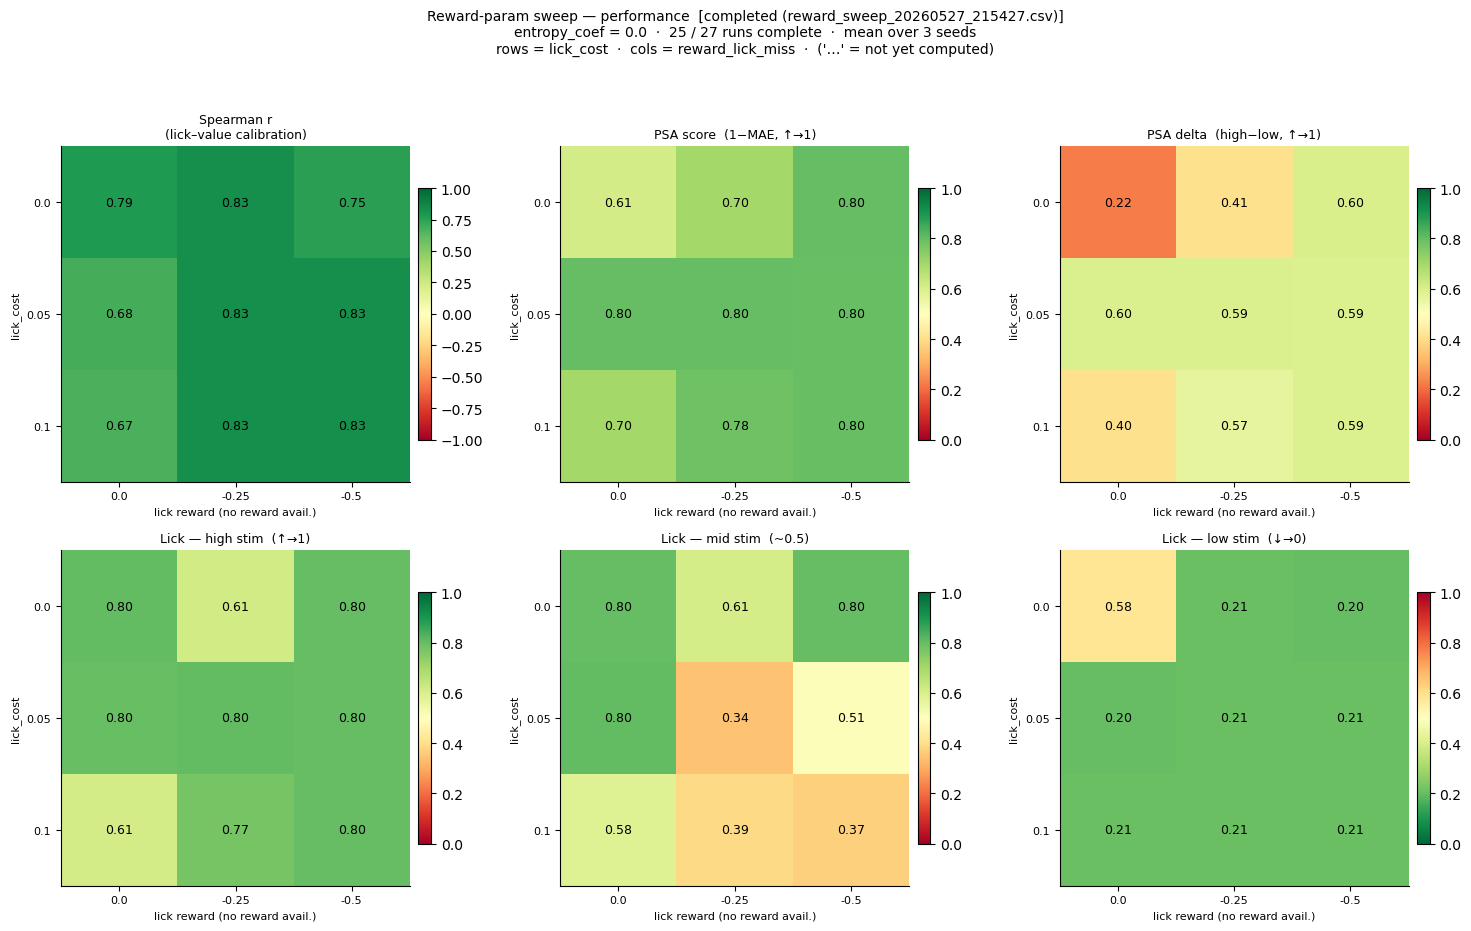

In [241]:
# ── Reward-param sweep overview (CSV-based) ───────────────────────────────────
# Reads reward_sweep_partial.csv (sweep in progress) or a completed
# reward_sweep_*.csv.  When entropy_coef varies, produces one set of heatmaps
# per entropy_coef value so each is clearly labelled.

_ENTROPY_COEF_VALS = [0.0, 0.01]
_LICK_FA_VALS    = [0.0, -0.25, -0.5]
_LICK_COST_VALS    = [0.0,  0.05,  0.1]
_BASE_SEED         = 42
_N_SEEDS           = 3
_SEEDS             = list(range(_BASE_SEED, _BASE_SEED + _N_SEEDS))

_partial_csv = _SWEEP_DIR / "reward_sweep_partial.csv"
_done_csvs   = sorted(_SWEEP_DIR.glob("reward_sweep_2*.csv"))

_rp_csv   = None
_rp_label = ""
if _partial_csv.exists():
    _rp_csv   = _partial_csv
    _rp_label = "partial — sweep in progress"
elif _done_csvs:
    _rp_csv   = _done_csvs[-1]
    _rp_label = f"completed ({_rp_csv.name})"

if _rp_csv is None:
    print("No reward-param sweep CSV found in", _SWEEP_DIR, "— skipping.")
else:
    import pandas as _pd
    _rp_raw = _pd.read_csv(_rp_csv)

    # backward compat: old CSVs used reward_lick_miss before the rename
    if "reward_lick_miss" in _rp_raw.columns and "reward_lick_fa" not in _rp_raw.columns:
        _rp_raw = _rp_raw.rename(columns={"reward_lick_miss": "reward_lick_fa"})

    # Detect entropy_coef dimension
    _ec_col_present = "entropy_coef" in _rp_raw.columns
    _ec_vals_found  = sorted(_rp_raw["entropy_coef"].unique()) if _ec_col_present else [None]
    _has_multi_ec   = len(_ec_vals_found) > 1

    _n_ec    = len(_ec_vals_found)
    _n_total = _n_ec * len(_LICK_FA_VALS) * len(_LICK_COST_VALS) * _N_SEEDS
    print(f"Reward sweep CSV : {_rp_csv.name}  [{_rp_label}]")
    print(f"  {len(_rp_raw)} / {_n_total} runs complete"
          + (f"  |  diverged: {int(_rp_raw['diverged'].sum())}" if "diverged" in _rp_raw else ""))
    if _has_multi_ec:
        print(f"  entropy_coef values: {_ec_vals_found} — producing one figure per ec")

    _n_miss  = len(_LICK_FA_VALS)
    _n_cost  = len(_LICK_COST_VALS)
    _miss_lbl = [str(v) for v in _LICK_FA_VALS]
    _cost_lbl = [str(v) for v in _LICK_COST_VALS]

    _PERF_METRICS = [
        ("spearman_r", "Spearman r\n(lick–value calibration)", -1, 1, "RdYlGn"),
        ("psa_score",  "PSA score  (1−MAE, ↑→1)",               0, 1, "RdYlGn"),
        ("psa_delta",  "PSA delta  (high−low, ↑→1)",             0, 1, "RdYlGn"),
        ("lick_high",  "Lick — high stim  (↑→1)",                0, 1, "RdYlGn"),
        ("lick_mid",   "Lick — mid stim  (~0.5)",                 0, 1, "RdYlGn"),
        ("lick_low",   "Lick — low stim  (↓→0)",                  0, 1, "RdYlGn_r"),
    ]

    for _ec in _ec_vals_found:
        # Slice to this entropy_coef (or use all rows if no ec column)
        if _ec is not None:
            _sub = _rp_raw[_rp_raw["entropy_coef"] == _ec].copy()
            _ec_label = f"entropy_coef = {_ec}"
            _ec_slug  = f"_ec{str(_ec).replace('.','p')}"
        else:
            _sub = _rp_raw
            _ec_label = ""
            _ec_slug  = ""

        # Full grid with NaN fill for missing combos
        _all_keys = _pd.DataFrame([
            {"reward_lick_fa": lm, "lick_cost": lc, "seed": s}
            for lm in _LICK_FA_VALS for lc in _LICK_COST_VALS for s in _SEEDS
        ])
        _merge_cols = ["reward_lick_fa", "lick_cost", "seed"]
        _sub_merge  = _sub[_merge_cols + [c for c in _sub.columns if c not in _merge_cols]]
        _rp_full = _all_keys.merge(_sub_merge, on=_merge_cols, how="left")

        def _rp_grid(col):
            g = np.full((_n_cost, _n_miss), np.nan)
            for ci, lc in enumerate(_LICK_COST_VALS):
                for mi, lm in enumerate(_LICK_FA_VALS):
                    vals = _rp_full.loc[
                        (_rp_full["lick_cost"] == lc) & (_rp_full["reward_lick_fa"] == lm), col
                    ].dropna()
                    if len(vals):
                        g[ci, mi] = float(vals.mean())
            return g

        fig, axes = plt.subplots(2, 3, figsize=(15, 9))
        for ax, (col, title, vmin, vmax, cmap) in zip(axes.flat, _PERF_METRICS):
            if col not in _rp_full.columns:
                ax.axis("off"); ax.set_title(f"{col}\n(not in CSV)"); continue
            data = _rp_grid(col)
            im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
            for ci in range(_n_cost):
                for mi in range(_n_miss):
                    v = data[ci, mi]
                    ax.text(mi, ci, f"{v:.2f}" if not np.isnan(v) else "…",
                            ha="center", va="center", fontsize=9,
                            color="black" if not np.isnan(v) else "gray")
            ax.set_xticks(range(_n_miss)); ax.set_xticklabels(_miss_lbl, fontsize=8)
            ax.set_yticks(range(_n_cost)); ax.set_yticklabels(_cost_lbl, fontsize=8)
            ax.set_xlabel("lick reward (no reward avail.)", fontsize=8)
            ax.set_ylabel("lick_cost", fontsize=8)
            ax.set_title(title, fontsize=9)
            plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)

        _n_done = int((~_rp_full["psa_score"].isna()).sum()) if "psa_score" in _rp_full else "?"
        _sub_total = len(_LICK_FA_VALS) * len(_LICK_COST_VALS) * _N_SEEDS
        fig.suptitle(
            f"Reward-param sweep — performance  [{_rp_label}]\n"
            + (f"{_ec_label}  ·  " if _ec_label else "")
            + f"{_n_done} / {_sub_total} runs complete  ·  mean over {_N_SEEDS} seeds\n"
            "rows = lick_cost  ·  cols = reward_lick_fa  ·  ('…' = not yet computed)",
            y=1.03, fontsize=10,
        )
        plt.tight_layout()
        fig.savefig(OV_FIGURES / f"fig_rp_performance{_ec_slug}.png", dpi=150, bbox_inches="tight")
        plt.show()


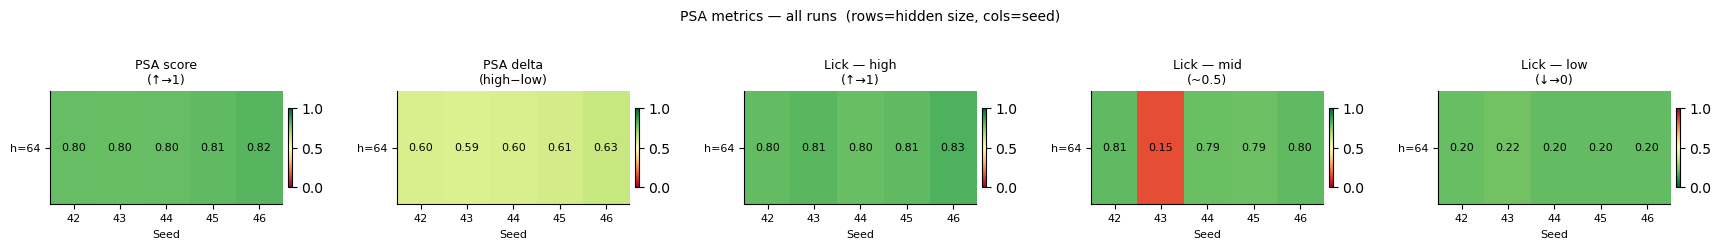

In [242]:
# ── PSA metric heatmaps (rows = hidden size, cols = seed) ────────────────────
_h_vals = sorted(ov_df["hidden_size"].unique())
_s_vals = sorted(ov_df["seed"].unique())

_METRICS = [
    ("psa_score",  "PSA score\n(↑→1)",      0, 1,  "RdYlGn"),
    ("psa_delta",  "PSA delta\n(high−low)",  0, 1,  "RdYlGn"),
    ("lick_high",  "Lick — high\n(↑→1)",    0, 1,  "RdYlGn"),
    ("lick_mid",   "Lick — mid\n(~0.5)",     0, 1,  "RdYlGn"),
    ("lick_low",   "Lick — low\n(↓→0)",     0, 1,  "RdYlGn_r"),
]

fig, axes = plt.subplots(1, len(_METRICS),
                         figsize=(3.5 * len(_METRICS), 0.9 * len(_h_vals) + 1.5))
for ax, (col, title, vmin, vmax, cmap) in zip(axes, _METRICS):
    data = np.full((len(_h_vals), len(_s_vals)), np.nan)
    for hi, h in enumerate(_h_vals):
        for si, s in enumerate(_s_vals):
            row = ov_df[(ov_df["hidden_size"] == h) & (ov_df["seed"] == s)]
            if len(row):
                data[hi, si] = float(row[col].iloc[0])
    im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
    for hi in range(len(_h_vals)):
        for si in range(len(_s_vals)):
            v = data[hi, si]
            if not np.isnan(v):
                ax.text(si, hi, f"{v:.2f}", ha="center", va="center", fontsize=8)
    ax.set_xticks(range(len(_s_vals)))
    ax.set_xticklabels([str(s) for s in _s_vals], fontsize=8)
    ax.set_yticks(range(len(_h_vals)))
    ax.set_yticklabels([f"h={h}" for h in _h_vals], fontsize=8)
    ax.set_xlabel("Seed", fontsize=8)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

fig.suptitle("PSA metrics — all runs  (rows=hidden size, cols=seed)", y=1.02, fontsize=10)
plt.tight_layout()
fig.savefig(OV_FIGURES / "fig1_psa_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

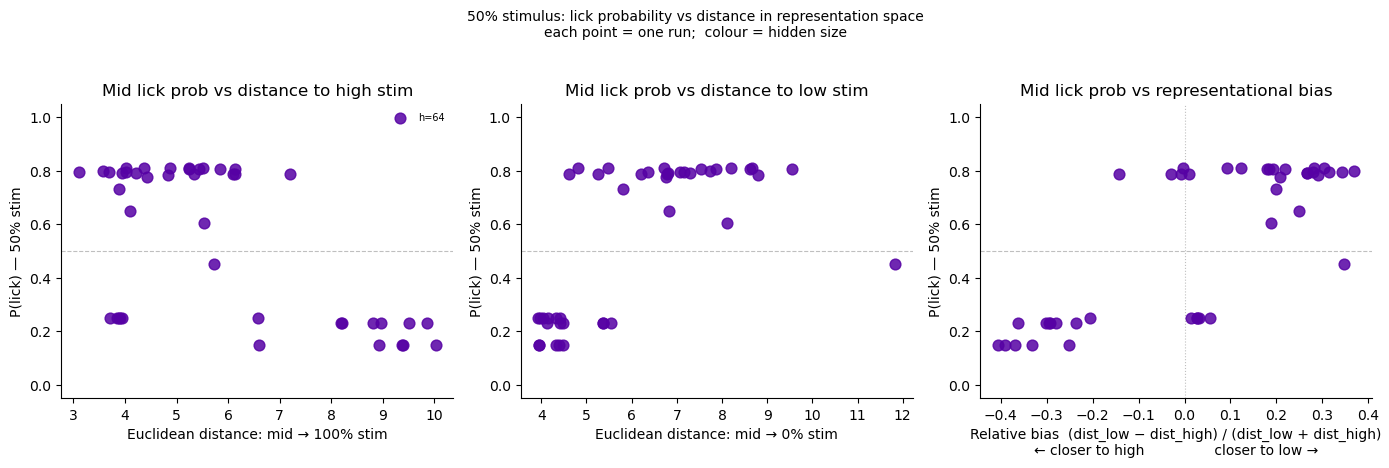

In [243]:
# ── Mid-stim lick prob vs representation distance ─────────────────────────────
_h_palette = plt.cm.plasma(np.linspace(0.15, 0.85, len(_h_vals)))
_h_color   = {h: c for h, c in zip(_h_vals, _h_palette)}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Panel 1: dist(mid, high) vs lick_mid
ax = axes[0]
for h in _h_vals:
    sub = ov_df[ov_df["hidden_size"] == h]
    ax.scatter(sub["dist_mid_high"], sub["lick_mid"],
               color=_h_color[h], s=60, alpha=0.85, label=f"h={h}", zorder=3)
ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Euclidean distance: mid → 100% stim")
ax.set_ylabel("P(lick) — 50% stim")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Mid lick prob vs distance to high stim")
ax.legend(fontsize=7, frameon=False)

# Panel 2: dist(mid, low) vs lick_mid
ax = axes[1]
for h in _h_vals:
    sub = ov_df[ov_df["hidden_size"] == h]
    ax.scatter(sub["dist_mid_low"], sub["lick_mid"],
               color=_h_color[h], s=60, alpha=0.85, label=f"h={h}", zorder=3)
ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Euclidean distance: mid → 0% stim")
ax.set_ylabel("P(lick) — 50% stim")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Mid lick prob vs distance to low stim")

# Panel 3: relative bias (dist_to_low - dist_to_high) / (dist_to_low + dist_to_high)
ax = axes[2]
_bias = (ov_df["dist_mid_low"] - ov_df["dist_mid_high"]) / \
        (ov_df["dist_mid_low"] + ov_df["dist_mid_high"])
for h in _h_vals:
    m = ov_df["hidden_size"] == h
    ax.scatter(_bias[m], ov_df.loc[m, "lick_mid"],
               color=_h_color[h], s=60, alpha=0.85, label=f"h={h}", zorder=3)
ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
ax.axvline(0,   color="gray", lw=0.8, ls=":",  alpha=0.5)
ax.set_xlabel("Relative bias  (dist_low − dist_high) / (dist_low + dist_high)\n"
              "← closer to low                closer to high →")
ax.set_ylabel("P(lick) — 50% stim")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Mid lick prob vs representational bias")

fig.suptitle("50% stimulus: lick probability vs distance in representation space\n"
             "each point = one run;  colour = hidden size", y=1.03, fontsize=10)
plt.tight_layout()
fig.savefig(OV_FIGURES / "fig2_representation_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

SI metric: range/|sum| + silent mask  (cogNN-style)
Stim cols: ['frac_stim0_r', 'frac_stim1_r', 'frac_stim2_r']
  frac_stim0_r: 42/43 non-NaN rows
  frac_stim1_r: 42/43 non-NaN rows
  frac_stim2_r: 42/43 non-NaN rows


/var/folders/8s/q649n2z56_1045fkqy4dygm00000gr/T/ipykernel_11952/3989181249.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


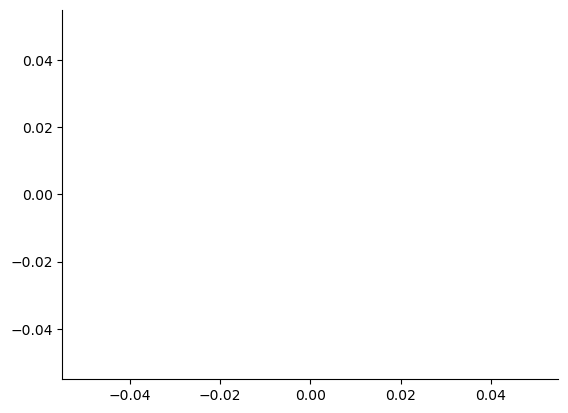

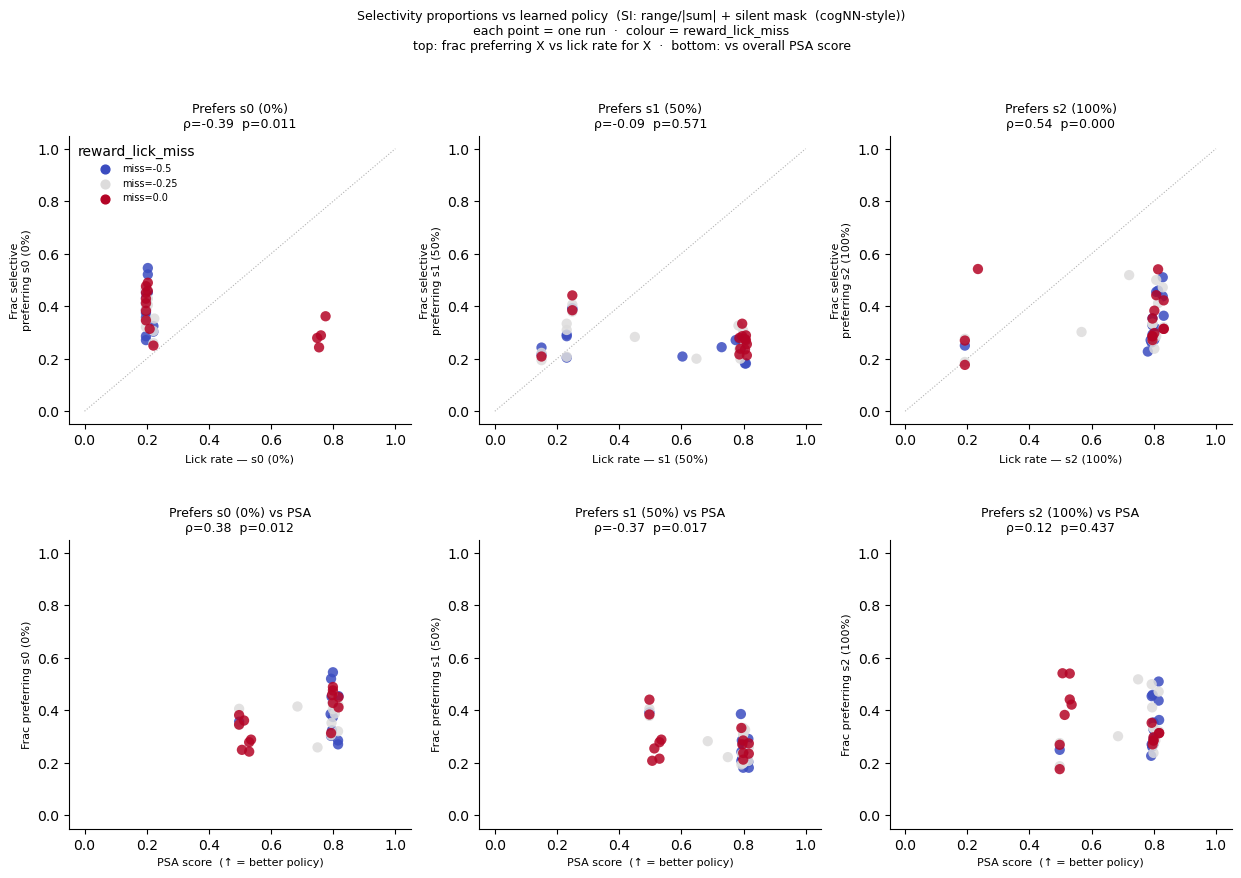

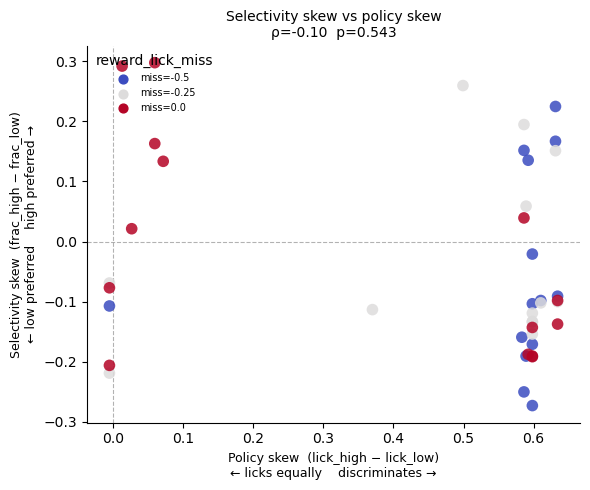

In [244]:
# ── Selectivity proportions vs learned policy / value ─────────────────────────
# Each point = one run.  Question: does the fraction of neurons preferring
# stimulus X correlate with (a) the lick rate for X, and (b) the PSA score?

if ov_df.empty or not (_stim_cols_r or _stim_cols):
    print("No runs loaded — skipping selectivity vs policy scatter.")
else:
    # Pick best available SI columns, falling back if all values are NaN
    if _stim_cols_r and not all(ov_df[sc].isna().all() for sc in _stim_cols_r if sc in ov_df.columns):
        _s_cols_use = _stim_cols_r
        _si_label   = "range/|sum| + silent mask  (cogNN-style)"
    elif _stim_cols_c and not all(ov_df[sc].isna().all() for sc in _stim_cols_c if sc in ov_df.columns):
        _s_cols_use = _stim_cols_c
        _si_label   = "max/sum  (concentration)"
    else:
        _s_cols_use = _stim_cols
        _si_label   = "1−mean/max  (peak)"

    _n_stim_ov = len(_s_cols_use)
    print(f"SI metric: {_si_label}")
    print(f"Stim cols: {_s_cols_use}")
    for sc in _s_cols_use:
        n_ok = int(ov_df[sc].notna().sum()) if sc in ov_df.columns else 0
        print(f"  {sc}: {n_ok}/{len(ov_df)} non-NaN rows")

    _has_ec_here = ("entropy_coef" in ov_df.columns and ov_df["entropy_coef"].nunique() > 1)
    _has_rp_here = (("reward_lick_fa" in ov_df.columns and ov_df["reward_lick_fa"].nunique() > 1) or
                    ("lick_cost"        in ov_df.columns and ov_df["lick_cost"].nunique()        > 1))

    if _has_ec_here:
        _ec_vals_u  = sorted(ov_df["entropy_coef"].unique())
        _ec_palette = {ec: plt.cm.Set1(i / max(1, len(_ec_vals_u) - 1))
                       for i, ec in enumerate(_ec_vals_u)}
        _pt_colors  = [_ec_palette[r] for r in ov_df["entropy_coef"]]
        _legend_handles = [plt.scatter([], [], color=c, s=40, label=f"ec={ec}")
                           for ec, c in _ec_palette.items()]
        _color_label = "entropy_coef"
    elif _has_rp_here:
        _lm_vals_ov = sorted(ov_df["reward_lick_fa"].unique())
        _lm_palette = {lm: plt.cm.coolwarm(i / max(1, len(_lm_vals_ov) - 1))
                       for i, lm in enumerate(_lm_vals_ov)}
        _pt_colors  = [_lm_palette[r] for r in ov_df["reward_lick_fa"]]
        _legend_handles = [plt.scatter([], [], color=c, s=40, label=f"miss={lm}")
                           for lm, c in _lm_palette.items()]
        _color_label = "reward_lick_fa"
    else:
        _h_vals_ov  = sorted(ov_df["hidden_size"].unique())
        _h_palette2 = {h: plt.cm.plasma(i / max(1, len(_h_vals_ov) - 1))
                       for i, h in enumerate(_h_vals_ov)}
        _pt_colors  = [_h_palette2[r] for r in ov_df["hidden_size"]]
        _legend_handles = [plt.scatter([], [], color=c, s=40, label=f"h={h}")
                           for h, c in _h_palette2.items()]
        _color_label = "hidden_size"

    _lick_cols = ["lick_low", "lick_mid", "lick_high"]   # must match stim order

    from scipy.stats import spearmanr as _sr

    # ── Figure 1: frac_stimX vs lick rate for that stimulus ───────────────────
    fig, axes = plt.subplots(2, _n_stim_ov, figsize=(5 * _n_stim_ov, 9),
                              gridspec_kw={"hspace": 0.4})
    if _n_stim_ov == 1:
        axes = axes.reshape(2, 1)

    for si, (sc, lc) in enumerate(zip(_s_cols_use, _lick_cols)):
        if sc not in ov_df.columns or lc not in ov_df.columns:
            continue
        stim_lbl = _stim_labels[si] if si < len(_stim_labels) else f"s{si}"

        ax = axes[0, si]
        x  = ov_df[lc].values
        y  = ov_df[sc].values
        ax.scatter(x, y, c=_pt_colors, s=55, alpha=0.85, edgecolors="none", zorder=3)
        ax.plot([0, 1], [0, 1], color="gray", lw=0.8, ls=":", alpha=0.6)
        valid = ~(np.isnan(x) | np.isnan(y))
        if valid.sum() > 2:
            rho, pval = _sr(x[valid], y[valid])
            ax.set_title(f"Prefers {stim_lbl}\nρ={rho:.2f}  p={pval:.3f}", fontsize=9)
        else:
            ax.set_title(f"Prefers {stim_lbl}  (n={valid.sum()} valid)", fontsize=9)
        ax.set_xlabel(f"Lick rate — {stim_lbl}", fontsize=8)
        ax.set_ylabel(f"Frac selective\npreferring {stim_lbl}", fontsize=8)
        ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)

        ax = axes[1, si]
        x2 = ov_df["psa_score"].values
        ax.scatter(x2, y, c=_pt_colors, s=55, alpha=0.85, edgecolors="none", zorder=3)
        valid2 = ~(np.isnan(x2) | np.isnan(y))
        if valid2.sum() > 2:
            rho2, pval2 = _sr(x2[valid2], y[valid2])
            ax.set_title(f"Prefers {stim_lbl} vs PSA\nρ={rho2:.2f}  p={pval2:.3f}", fontsize=9)
        else:
            ax.set_title(f"Prefers {stim_lbl} vs PSA  (n={valid2.sum()} valid)", fontsize=9)
        ax.set_xlabel("PSA score  (↑ = better policy)", fontsize=8)
        ax.set_ylabel(f"Frac preferring {stim_lbl}", fontsize=8)
        ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)

    axes[0, 0].legend(handles=_legend_handles, fontsize=7, frameon=False,
                      title=_color_label, loc="upper left")
    fig.suptitle(
        f"Selectivity proportions vs learned policy  (SI: {_si_label})\n"
        f"each point = one run  ·  colour = {_color_label}\n"
        "top: frac preferring X vs lick rate for X  ·  bottom: vs overall PSA score",
        y=1.02, fontsize=9,
    )
    plt.tight_layout()
    fig.savefig(OV_FIGURES / "fig4_selectivity_vs_policy.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Figure 2: selectivity skew vs policy skew ─────────────────────────────
    if (_s_cols_use[0] in ov_df.columns and _s_cols_use[-1] in ov_df.columns and
            "lick_high" in ov_df.columns and "lick_low" in ov_df.columns):
        sel_skew  = ov_df[_s_cols_use[-1]] - ov_df[_s_cols_use[0]]
        lick_skew = ov_df["lick_high"]     - ov_df["lick_low"]

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(lick_skew, sel_skew, c=_pt_colors, s=70,
                   alpha=0.85, edgecolors="none", zorder=3)
        ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.6)
        ax.axvline(0, color="gray", lw=0.8, ls="--", alpha=0.6)
        ax.set_xlabel("Policy skew  (lick_high − lick_low)\n← licks equally    discriminates →",
                      fontsize=9)
        ax.set_ylabel("Selectivity skew  (frac_high − frac_low)\n← low preferred    high preferred →",
                      fontsize=9)
        valid_sk = ~(lick_skew.isna() | sel_skew.isna())
        if valid_sk.sum() > 2:
            rho_sk, p_sk = _sr(lick_skew[valid_sk], sel_skew[valid_sk])
            ax.set_title(f"Selectivity skew vs policy skew\nρ={rho_sk:.2f}  p={p_sk:.3f}",
                         fontsize=10)
        else:
            ax.set_title(f"Selectivity skew vs policy skew  (n={valid_sk.sum()} valid)",
                         fontsize=10)
        ax.legend(handles=_legend_handles, fontsize=7, frameon=False,
                  title=_color_label, loc="upper left")
        plt.tight_layout()
        fig.savefig(OV_FIGURES / "fig4b_selectivity_skew_vs_policy_skew.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

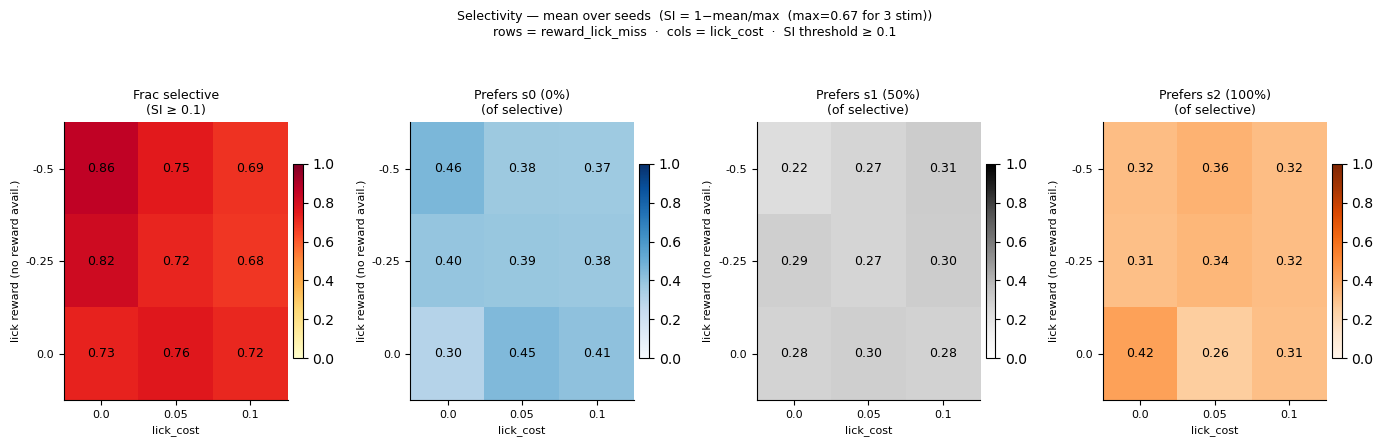

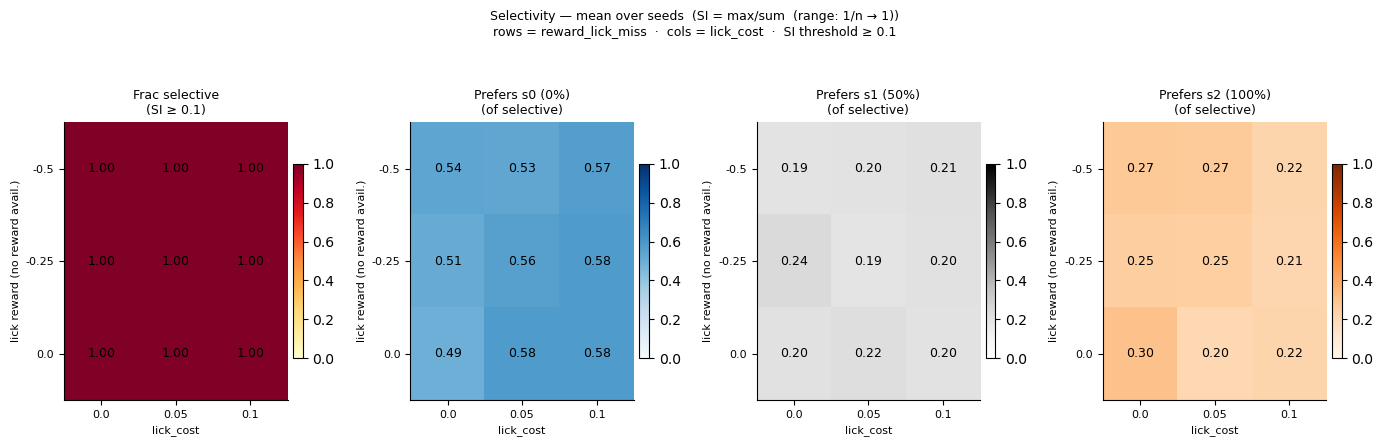

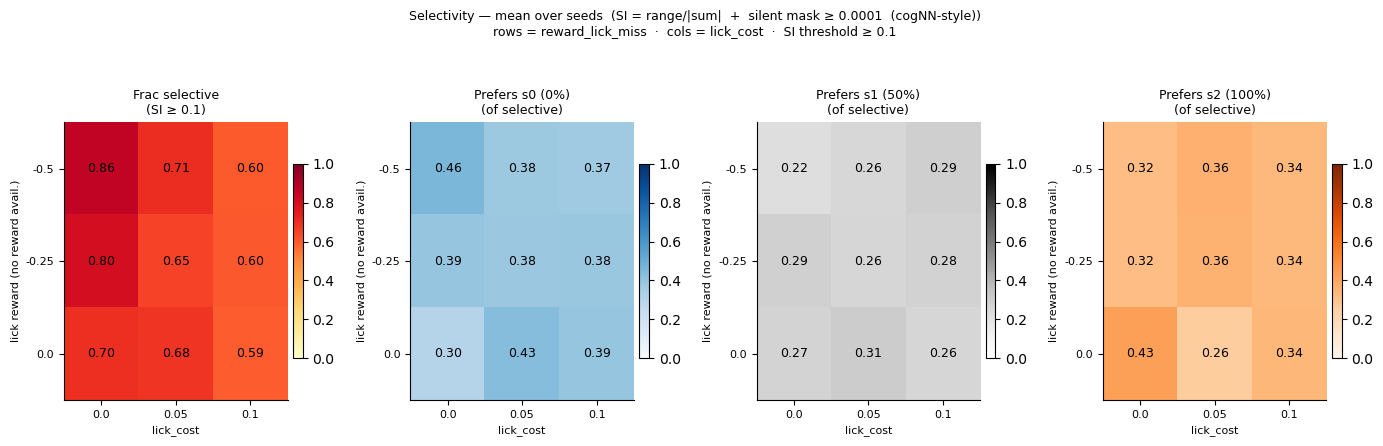

In [245]:
# ── Selectivity: preferred stimulus breakdown across all runs ──────────────────
if ov_df.empty or not _stim_cols:
    print("No PKL-based runs loaded — skipping selectivity overview.")
else:
    _stim_labels      = _stim_names if _stim_names else [f"s{i}" for i in range(len(_stim_cols))]
    _stim_plot_colors = [f"C{i}" for i in range(len(_stim_cols))]

    _has_rp = (("reward_lick_fa" in ov_df.columns and ov_df["reward_lick_fa"].nunique() > 1) or
               ("lick_cost"        in ov_df.columns and ov_df["lick_cost"].nunique()        > 1))
    _has_ec = ("entropy_coef" in ov_df.columns and ov_df["entropy_coef"].nunique() > 1)

    _SI_VARIANTS = [
        (f"SI = 1−mean/max  (max={1-1/len(_stim_cols):.2f} for {len(_stim_cols)} stim)",
         "frac_selective",   _stim_cols,   "peak"),
        ("SI = max/sum  (range: 1/n → 1)",
         "frac_selective_c", _stim_cols_c, "conc"),
        (f"SI = range/|sum|  +  silent mask ≥ {_SILENT_THR}  (cogNN-style)",
         "frac_selective_r", _stim_cols_r, "range"),
    ]

    if _has_rp:
        # ── Reward-param sweep: heatmaps (rows=lick_fa, cols=lick_cost) ──────
        # When entropy_coef also varies, produce one set of heatmaps per ec value.
        _lm_vals = sorted(ov_df["reward_lick_fa"].unique())
        _lc_vals = sorted(ov_df["lick_cost"].unique())
        _ec_vals = sorted(ov_df["entropy_coef"].unique()) if _has_ec else [None]

        def _rp_sel_grid(sub_df, col):
            g = np.full((len(_lm_vals), len(_lc_vals)), np.nan)
            for ri, lm in enumerate(_lm_vals):
                for ci, lc in enumerate(_lc_vals):
                    vals = sub_df.loc[
                        (sub_df["reward_lick_fa"] == lm) & (sub_df["lick_cost"] == lc), col
                    ].dropna()
                    if len(vals):
                        g[ri, ci] = float(vals.mean())
            return g

        for _ec in _ec_vals:
            _ec_label = f"  [entropy_coef={_ec}]" if _ec is not None else ""
            _sub = ov_df[ov_df["entropy_coef"] == _ec] if _ec is not None else ov_df
            _ec_slug = f"_ec{str(_ec).replace('.','p')}" if _ec is not None else ""

            for variant_label, sel_col, s_cols, vkey in _SI_VARIANTS:
                if sel_col not in _sub.columns or _sub[sel_col].isna().all():
                    continue

                all_cols = [(sel_col, f"Frac selective\n(SI ≥ {_SI_THRESH})", "YlOrRd")] + [
                    (sc, f"Prefers {_stim_labels[i]}\n(of selective)",
                     "Blues" if i == 0 else "Greys" if i == 1 else "Oranges")
                    for i, sc in enumerate(s_cols) if sc in _sub.columns
                ]
                n_panels = len(all_cols)
                fig, axes = plt.subplots(1, n_panels,
                                         figsize=(3.5 * n_panels, 0.9 * len(_lm_vals) + 1.5))
                if n_panels == 1:
                    axes = [axes]

                for ax, (col, title, cmap) in zip(axes, all_cols):
                    data = _rp_sel_grid(_sub, col)
                    im   = ax.imshow(data, vmin=0, vmax=1, cmap=cmap, aspect="auto")
                    for ri in range(len(_lm_vals)):
                        for ci in range(len(_lc_vals)):
                            v = data[ri, ci]
                            ax.text(ci, ri, f"{v:.2f}" if not np.isnan(v) else "…",
                                    ha="center", va="center", fontsize=9,
                                    color="black" if not np.isnan(v) else "gray")
                    ax.set_xticks(range(len(_lc_vals)));  ax.set_xticklabels([str(v) for v in _lc_vals], fontsize=8)
                    ax.set_yticks(range(len(_lm_vals)));  ax.set_yticklabels([str(v) for v in _lm_vals], fontsize=8)
                    ax.set_xlabel("lick_cost", fontsize=8)
                    ax.set_ylabel("lick reward (no reward avail.)", fontsize=8)
                    ax.set_title(title, fontsize=9)
                    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

                fig.suptitle(
                    f"Selectivity — mean over seeds  ({variant_label}){_ec_label}\n"
                    f"rows = reward_lick_fa  ·  cols = lick_cost  ·  SI threshold ≥ {_SI_THRESH}",
                    y=1.05, fontsize=9,
                )
                plt.tight_layout()
                fig.savefig(OV_FIGURES / f"fig3_selectivity_{vkey}{_ec_slug}.png",
                            dpi=150, bbox_inches="tight")
                plt.show()

    else:
        # ── Hidden-size sweep: heatmap (h × seed) + per-run stacked bar ──────
        _h_vals_u = sorted(ov_df["hidden_size"].unique())
        _s_vals_u = sorted(ov_df["seed"].unique())

        for variant_label, sel_col, s_cols, vkey in _SI_VARIANTS:
            if sel_col not in ov_df.columns or ov_df[sel_col].isna().all():
                continue
            all_cols = [(sel_col, f"Frac selective\n(SI ≥ {_SI_THRESH})", "YlOrRd")] + [
                (sc, f"Prefers {_stim_labels[i]}\n(of selective)",
                 "Blues" if i == 0 else "Greys" if i == 1 else "Oranges")
                for i, sc in enumerate(s_cols) if sc in ov_df.columns
            ]
            fig, axes = plt.subplots(1, len(all_cols),
                                     figsize=(3.5 * len(all_cols), 0.9 * len(_h_vals_u) + 1.5))
            if len(all_cols) == 1:
                axes = [axes]
            for ax, (col, title, cmap) in zip(axes, all_cols):
                data = np.full((len(_h_vals_u), len(_s_vals_u)), np.nan)
                for hi, h in enumerate(_h_vals_u):
                    for si, s in enumerate(_s_vals_u):
                        rows = ov_df[(ov_df["hidden_size"] == h) & (ov_df["seed"] == s)]
                        if len(rows):
                            data[hi, si] = float(rows[col].iloc[0])
                im = ax.imshow(data, vmin=0, vmax=1, cmap=cmap, aspect="auto")
                for hi in range(len(_h_vals_u)):
                    for si in range(len(_s_vals_u)):
                        v = data[hi, si]
                        if not np.isnan(v):
                            ax.text(si, hi, f"{v:.2f}", ha="center", va="center", fontsize=8)
                ax.set_xticks(range(len(_s_vals_u))); ax.set_xticklabels([str(s) for s in _s_vals_u], fontsize=8)
                ax.set_yticks(range(len(_h_vals_u))); ax.set_yticklabels([f"h={h}" for h in _h_vals_u], fontsize=8)
                ax.set_xlabel("Seed", fontsize=8); ax.set_title(title, fontsize=9)
                plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            fig.suptitle(f"Selectivity — all runs  ({variant_label})\n"
                         f"threshold SI ≥ {_SI_THRESH}", y=1.05, fontsize=9)
            plt.tight_layout()
            fig.savefig(OV_FIGURES / f"fig3_selectivity_{vkey}.png", dpi=150, bbox_inches="tight")
            plt.show()

        # Stacked bar: one bar per run
        _sorted   = ov_df.sort_values(["hidden_size", "seed"]).reset_index(drop=True)
        _h_vals_s = sorted(_sorted["hidden_size"].unique())
        _palette  = plt.cm.plasma(np.linspace(0.15, 0.85, len(_h_vals_s)))
        _xlabels  = [f"h={r.hidden_size}\ns{r.seed}" for _, r in _sorted.iterrows()]
        _bar_cols = [_palette[_h_vals_s.index(r.hidden_size)] for _, r in _sorted.iterrows()]
        _x = np.arange(len(_sorted))

        for variant_label, sel_col, s_cols, vkey in _SI_VARIANTS:
            if sel_col not in _sorted.columns:
                continue
            from matplotlib.patches import Patch as _Patch
            fig, axes = plt.subplots(2, 1, figsize=(max(10, len(_sorted) * 0.75), 8),
                                      gridspec_kw={"height_ratios": [1, 2]})
            ax = axes[0]
            ax.bar(_x, _sorted[sel_col].fillna(0), color=_bar_cols, alpha=0.85, edgecolor="white")
            ax.set_xticks(_x); ax.set_xticklabels(_xlabels, fontsize=6)
            ax.set_ylabel("Frac selective", fontsize=8); ax.set_ylim(0, 1.05)
            ax.set_title(f"Fraction selective  ({variant_label}, threshold≥{_SI_THRESH})", fontsize=8)
            ax.legend(handles=[_Patch(color=_palette[i], label=f"h={v}")
                                for i, v in enumerate(_h_vals_s)],
                      fontsize=7, frameon=False, loc="upper right")
            ax = axes[1]
            _bottoms = np.zeros(len(_sorted))
            for i, sc in enumerate(s_cols):
                if sc not in _sorted.columns:
                    continue
                _vals = _sorted[sc].fillna(0).values
                ax.bar(_x, _vals, bottom=_bottoms, color=_stim_plot_colors[i],
                       alpha=0.85, label=_stim_labels[i], edgecolor="white")
                for xi, (v, b) in enumerate(zip(_vals, _bottoms)):
                    if v > 0.06:
                        ax.text(xi, b + v/2, f"{v:.2f}", ha="center", va="center",
                                fontsize=6, color="white", fontweight="bold")
                _bottoms += _vals
            ax.set_xticks(_x); ax.set_xticklabels(_xlabels, fontsize=6)
            ax.set_ylabel("Fraction of selective neurons", fontsize=8); ax.set_ylim(0, 1.05)
            ax.set_title(f"Preferred stimulus  ({variant_label})", fontsize=8)
            ax.legend(fontsize=7, frameon=False, loc="upper right", title="Preferred stim")
            fig.suptitle(f"Preferred stimulus composition — all runs  ({variant_label})", y=1.01, fontsize=10)
            plt.tight_layout()
            fig.savefig(OV_FIGURES / f"fig3b_selectivity_composition_{vkey}.png",
                        dpi=150, bbox_inches="tight")
            plt.show()

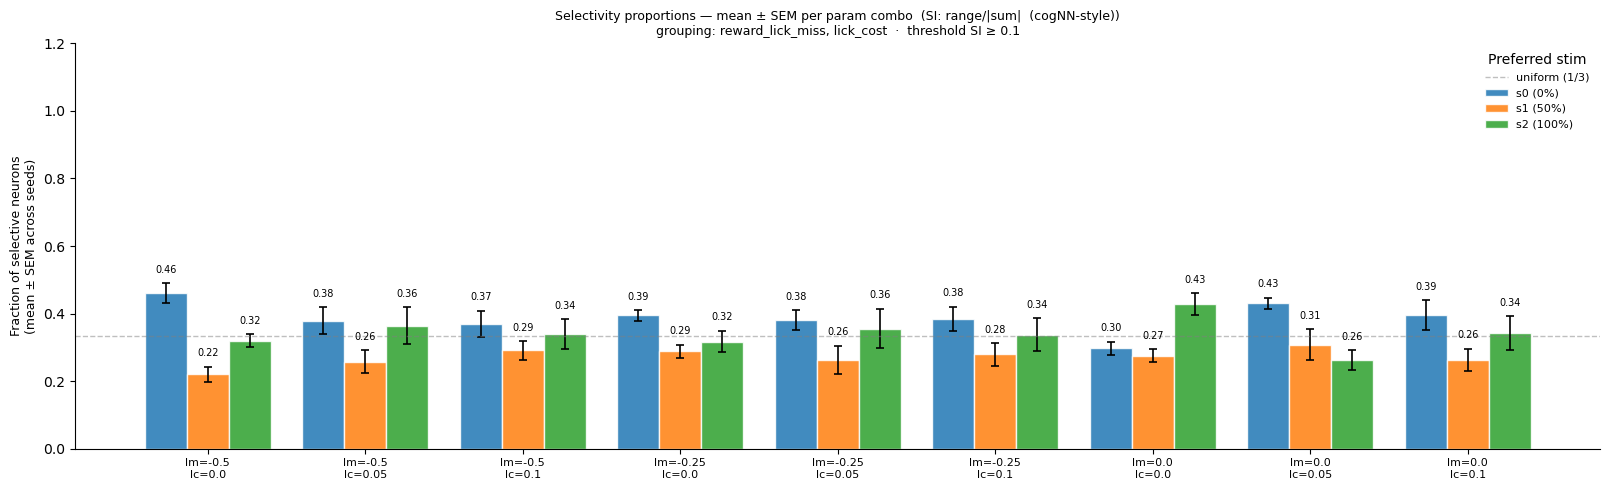

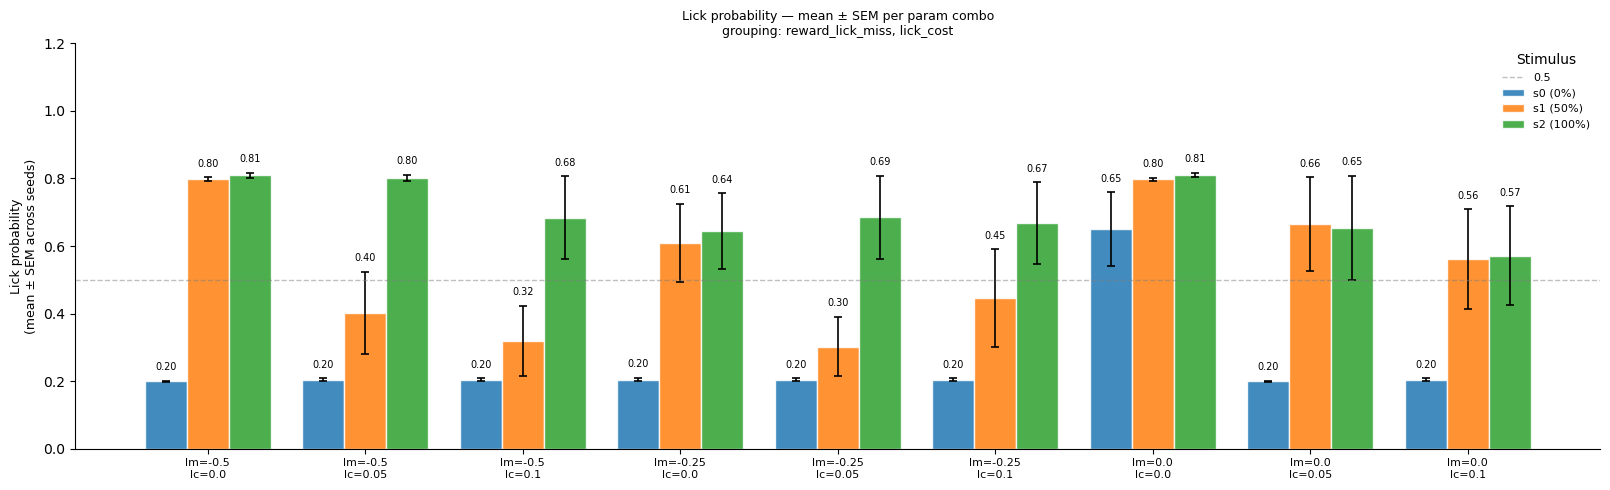

In [246]:
# ── Selectivity proportions: mean ± SEM across seeds, per param combo ─────────
if ov_df.empty or not (_stim_cols_r or _stim_cols_c or _stim_cols):
    print("No runs loaded — skipping mean selectivity bar plot.")
else:
    # Pick best available stim columns
    if _stim_cols_r and not all(ov_df[sc].isna().all() for sc in _stim_cols_r if sc in ov_df.columns):
        _sc_bar = [sc for sc in _stim_cols_r if sc in ov_df.columns]
        _si_bar_label = "range/|sum|  (cogNN-style)"
    elif _stim_cols_c and not all(ov_df[sc].isna().all() for sc in _stim_cols_c if sc in ov_df.columns):
        _sc_bar = [sc for sc in _stim_cols_c if sc in ov_df.columns]
        _si_bar_label = "max/sum"
    else:
        _sc_bar = [sc for sc in _stim_cols if sc in ov_df.columns]
        _si_bar_label = "1−mean/max"

    _stim_labels_bar = _stim_names if _stim_names else [f"s{i}" for i in range(len(_sc_bar))]

    # Group by all params that vary, excluding seed
    _cand_gcols = ["entropy_coef", "reward_lick_fa", "lick_cost", "hidden_size"]
    _group_cols = [c for c in _cand_gcols if c in ov_df.columns and ov_df[c].nunique() > 1]
    if not _group_cols:
        _group_cols = [c for c in _cand_gcols if c in ov_df.columns][:1]

    if not _group_cols:
        print("No grouping columns found — cannot produce mean bar plot.")
    else:
        _grp    = ov_df.groupby(_group_cols)
        _mean_b = _grp[_sc_bar].mean().reset_index()
        _sem_b  = _grp[_sc_bar].sem().reset_index()

        _label_map = {"entropy_coef": "ec", "reward_lick_fa": "lnr",
                      "lick_cost": "lc", "hidden_size": "h"}
        def _combo_label(row):
            return "\n".join(f"{_label_map.get(c, c)}={row[c]}" for c in _group_cols)

        _mean_b["_label"] = _mean_b.apply(_combo_label, axis=1)

        n_combos = len(_mean_b)
        n_stim_b = len(_sc_bar)
        _w  = 0.8 / n_stim_b
        _xb = np.arange(n_combos)

        fig, ax = plt.subplots(figsize=(max(8, n_combos * 1.8), 5))
        for si, sc in enumerate(_sc_bar):
            offset = (si - (n_stim_b - 1) / 2) * _w
            _m = _mean_b[sc].fillna(0).values
            _e = _sem_b[sc].fillna(0).values
            ax.bar(_xb + offset, _m, width=_w,
                   color=f"C{si}", alpha=0.85, label=_stim_labels_bar[si],
                   edgecolor="white", yerr=_e, capsize=3,
                   error_kw={"lw": 1.2, "capthick": 1.2})
            for xi, (m_v, e_v) in enumerate(zip(_m, _e)):
                if m_v > 0.02:
                    ax.text(_xb[xi] + offset, m_v + e_v + 0.025,
                            f"{m_v:.2f}", ha="center", va="bottom", fontsize=7)

        ax.axhline(1 / n_stim_b, color="gray", lw=1, ls="--", alpha=0.5,
                   label=f"uniform (1/{n_stim_b})")
        ax.set_xticks(_xb)
        ax.set_xticklabels(_mean_b["_label"].values, fontsize=8)
        ax.set_ylabel("Fraction of selective neurons\n(mean \u00b1 SEM across seeds)", fontsize=9)
        ax.set_ylim(0, 1.2)
        ax.legend(title="Preferred stim", fontsize=8, frameon=False)
        ax.set_title(
            f"Selectivity proportions \u2014 mean \u00b1 SEM per param combo  (SI: {_si_bar_label})\n"
            f"grouping: {', '.join(_group_cols)}  \u00b7  threshold SI \u2265 {_SI_THRESH}",
            fontsize=9,
        )
        plt.tight_layout()
        fig.savefig(OV_FIGURES / "fig3c_selectivity_mean_per_combo.png",
                    dpi=150, bbox_inches="tight")
        plt.show()


        # ── Lick probability: mean ± SEM across seeds, per param combo ────────────
        _lick_cols  = ["lick_low", "lick_mid", "lick_high"]
        _lick_labels = _stim_labels_bar if len(_stim_labels_bar) == 3 else ["low", "mid", "high"]
        _lick_present = [c for c in _lick_cols if c in ov_df.columns]

        if _lick_present:
            _mean_l = _grp[_lick_present].mean().reset_index()
            _sem_l  = _grp[_lick_present].sem().reset_index()
            _mean_l["_label"] = _mean_l.apply(_combo_label, axis=1)

            n_lick_b = len(_lick_present)
            _wl = 0.8 / n_lick_b
            _xl = np.arange(n_combos)

            fig, ax = plt.subplots(figsize=(max(8, n_combos * 1.8), 5))
            for li, (lc_col, ll) in enumerate(zip(_lick_present,
                                                   _lick_labels[-n_lick_b:])):
                offset = (li - (n_lick_b - 1) / 2) * _wl
                _m = _mean_l[lc_col].fillna(np.nan).values
                _e = _sem_l[lc_col].fillna(0).values
                ax.bar(_xl + offset, _m, width=_wl,
                       color=f"C{li}", alpha=0.85, label=ll,
                       edgecolor="white", yerr=_e, capsize=3,
                       error_kw={"lw": 1.2, "capthick": 1.2})
                for xi, (m_v, e_v) in enumerate(zip(_m, _e)):
                    if not np.isnan(m_v) and m_v > 0.02:
                        ax.text(_xl[xi] + offset, m_v + e_v + 0.025,
                                f"{m_v:.2f}", ha="center", va="bottom", fontsize=7)

            ax.axhline(0.5, color="gray", lw=1, ls="--", alpha=0.5, label="0.5")
            ax.set_xticks(_xl)
            ax.set_xticklabels(_mean_l["_label"].values, fontsize=8)
            ax.set_ylabel("Lick probability\n(mean \u00b1 SEM across seeds)", fontsize=9)
            ax.set_ylim(0, 1.2)
            ax.legend(title="Stimulus", fontsize=8, frameon=False)
            ax.set_title(
                "Lick probability \u2014 mean \u00b1 SEM per param combo\n"
                f"grouping: {', '.join(_group_cols)}",
                fontsize=9,
            )
            plt.tight_layout()
            fig.savefig(OV_FIGURES / "fig3d_lick_prob_mean_per_combo.png",
                        dpi=150, bbox_inches="tight")
            plt.show()


In [ ]:
# ── selection controls ────────────────────────────────────────────────────────
# Or point directly to a pkl to skip auto-selection entirely

# ── auto-select ───────────────────────────────────────────────────────────────
if VIS_DATA_PATH is None:
    pkls = sorted(SWEEP_DIR.rglob("vis_data.pkl")) if SWEEP_DIR.exists() else []
    if not pkls:
        print(f"⚠  No vis_data.pkl found under {SWEEP_DIR}.")
        print("   Run the sweep first, or set VIS_DATA_PATH directly in the config cell.")
        pkls = None

    candidates = []
    for p in (pkls or []):
        with open(p, "rb") as f:
            d = pickle.load(f)
        candidates.append({
            "path":             p,
            "hidden_size":      d.get("hidden_size", -1),
            "seed":             d.get("seed", -1),
            "entropy_coef":     d.get("entropy_coef", np.nan),
            "reward_lick_fa": d.get("reward_lick_fa", np.nan),
            "lick_cost":        d.get("lick_cost", np.nan),
            "psa_score":        d.get("psa_results", {0: {"psa_score": np.nan}})[0].get("psa_score", np.nan),
        })

    if SELECT_HIDDEN_SIZE is not None:
        candidates = [c for c in candidates if c["hidden_size"] == SELECT_HIDDEN_SIZE]
        if not candidates:
            raise ValueError(f"No runs with hidden_size={SELECT_HIDDEN_SIZE}")

    if SELECT_ENTROPY_COEF is not None:
        candidates = [c for c in candidates if c["entropy_coef"] == SELECT_ENTROPY_COEF]
        if not candidates:
            raise ValueError(f"No runs with entropy_coef={SELECT_ENTROPY_COEF}")

    if SELECT_LICK_FA is not None:
        candidates = [c for c in candidates if c["reward_lick_fa"] == SELECT_LICK_FA]
        if not candidates:
            raise ValueError(f"No runs with reward_lick_fa={SELECT_LICK_FA}")

    if SELECT_LICK_COST is not None:
        candidates = [c for c in candidates if c["lick_cost"] == SELECT_LICK_COST]
        if not candidates:
            raise ValueError(f"No runs with lick_cost={SELECT_LICK_COST}")

    if SELECT_SEED is not None:
        matches = [c for c in candidates if c["seed"] == SELECT_SEED]
        if not matches:
            raise ValueError(f"No run with seed={SELECT_SEED}")
        chosen = matches[0]
    else:
        chosen = max(candidates, key=lambda c: c["psa_score"] if not np.isnan(c["psa_score"]) else -np.inf)

    VIS_DATA_PATH = chosen["path"] if candidates else None
    print(f"Selected: ec={chosen['entropy_coef']}  h={chosen['hidden_size']}  "
          f"seed={chosen['seed']}  miss={chosen['reward_lick_fa']}  "
          f"cost={chosen['lick_cost']}  PSA={chosen['psa_score']:.3f}")
    print(f"  {VIS_DATA_PATH}")

    print(f"\nAll available runs ({len(candidates)} total):")
    for c in sorted(candidates, key=lambda c: (
        c.get("entropy_coef") or 0, c.get("reward_lick_fa") or 0,
        c.get("lick_cost") or 0, c["hidden_size"], c["seed"]
    )):
        marker = " ◀" if c["path"] == VIS_DATA_PATH else ""
        print(f"  ec={c['entropy_coef']:<5}  miss={c['reward_lick_fa']:<6}  "
              f"cost={c['lick_cost']:<5}  h={c['hidden_size']:<4}  "
              f"seed={c['seed']}  PSA={c['psa_score']:.3f}{marker}")

if VIS_DATA_PATH is not None:
    with open(VIS_DATA_PATH, "rb") as f:
        vd = pickle.load(f)

    RUN_DIR  = VIS_DATA_PATH.parent
    RUN_ID   = vd.get("run_id", RUN_DIR.name)
    FIGURES  = RUN_DIR / "figures"
    FIGURES.mkdir(exist_ok=True)
    device   = torch.device("cpu")

    RUN_FIGURES_GLOBAL = OV_FIGURES / f"h{vd['hidden_size']}_seed{vd['seed']}"
    RUN_FIGURES_GLOBAL.mkdir(parents=True, exist_ok=True)

    def save_run_fig(fig, filename):
        fig.savefig(FIGURES / filename, dpi=150, bbox_inches="tight")
        fig.savefig(RUN_FIGURES_GLOBAL / filename, dpi=150, bbox_inches="tight")

    print(f"\nRun: {RUN_ID}")
    print(f"Results figures : {FIGURES}")
    print(f"Global figures  : {RUN_FIGURES_GLOBAL}")

Selected: ec=0.01  h=64  seed=43  miss=0.0  cost=0.05  PSA=0.940
  ../results/26_05_26_sweep_entropy_params/RNN_ec0p01_lm0p0_lc0p05_h64_seed43_20260526_181139/vis_data.pkl

All available runs (47 total):
  ec=0.0    miss=-0.5    cost=0.0    h=64    seed=42  PSA=0.910
  ec=0.0    miss=-0.5    cost=0.0    h=64    seed=43  PSA=0.935
  ec=0.0    miss=-0.5    cost=0.05   h=64    seed=42  PSA=0.910
  ec=0.0    miss=-0.5    cost=0.05   h=64    seed=43  PSA=0.940
  ec=0.0    miss=-0.5    cost=0.05   h=64    seed=44  PSA=0.920
  ec=0.0    miss=-0.5    cost=0.1    h=64    seed=42  PSA=0.910
  ec=0.0    miss=-0.5    cost=0.1    h=64    seed=43  PSA=0.940
  ec=0.0    miss=-0.5    cost=0.1    h=64    seed=44  PSA=0.920
  ec=0.0    miss=-0.25   cost=0.0    h=64    seed=42  PSA=0.910
  ec=0.0    miss=-0.25   cost=0.0    h=64    seed=43  PSA=0.940
  ec=0.0    miss=-0.25   cost=0.05   h=64    seed=42  PSA=0.910
  ec=0.0    miss=-0.25   cost=0.05   h=64    seed=43  PSA=0.940
  ec=0.0    miss=-0.25   cos

In [248]:
# ── unpack vis_data ───────────────────────────────────────────────────────────
value_matrix     = vd["value_matrix"]
n_stimuli        = vd["n_stimuli"]
n_contexts       = vd["n_contexts"]
stimuli          = vd["stimuli"]
contexts         = vd["contexts"]
stim_group_info  = vd["stim_group_info"]
reward_timesteps = vd["reward_timesteps"]
stim_timesteps   = vd["stim_timesteps"]
all_trial_data   = vd["all_trial_data"]
infer_trial_data = vd["infer_trial_data"]
infer_act        = vd["infer_activations"]
hidden_size      = vd["hidden_size"]
lick_sc          = vd["lick_sc"]
psa_results      = vd["psa_results"]

# derived inference arrays
inf_stim  = np.array([d["stimulus"]  for d in infer_trial_data])
inf_ctx   = np.array([d["context"]   for d in infer_trial_data])
inf_lick  = np.array([d["licked"]    for d in infer_trial_data])
inf_vest  = np.array([d["value_estimate"] for d in infer_trial_data])
inf_ravail = np.array([d["reward_available"] for d in infer_trial_data], dtype=bool)

ctx_colors  = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]
stim_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

print(f"hidden_size={hidden_size}  n_stimuli={n_stimuli}  n_contexts={n_contexts}")
print(f"PSA score: {psa_results[0]['psa_score']:.3f}  "
      f"high={psa_results[0]['high_lick']:.3f}  "
      f"mid={psa_results[0]['mid_lick']:.3f}  "
      f"low={psa_results[0]['low_lick']:.3f}")

hidden_size=64  n_stimuli=3  n_contexts=1
PSA score: 0.940  high=0.910  mid=0.100  low=0.030


## § 1 — Training and inference behaviour

/var/folders/8s/q649n2z56_1045fkqy4dygm00000gr/T/ipykernel_11952/3260076694.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


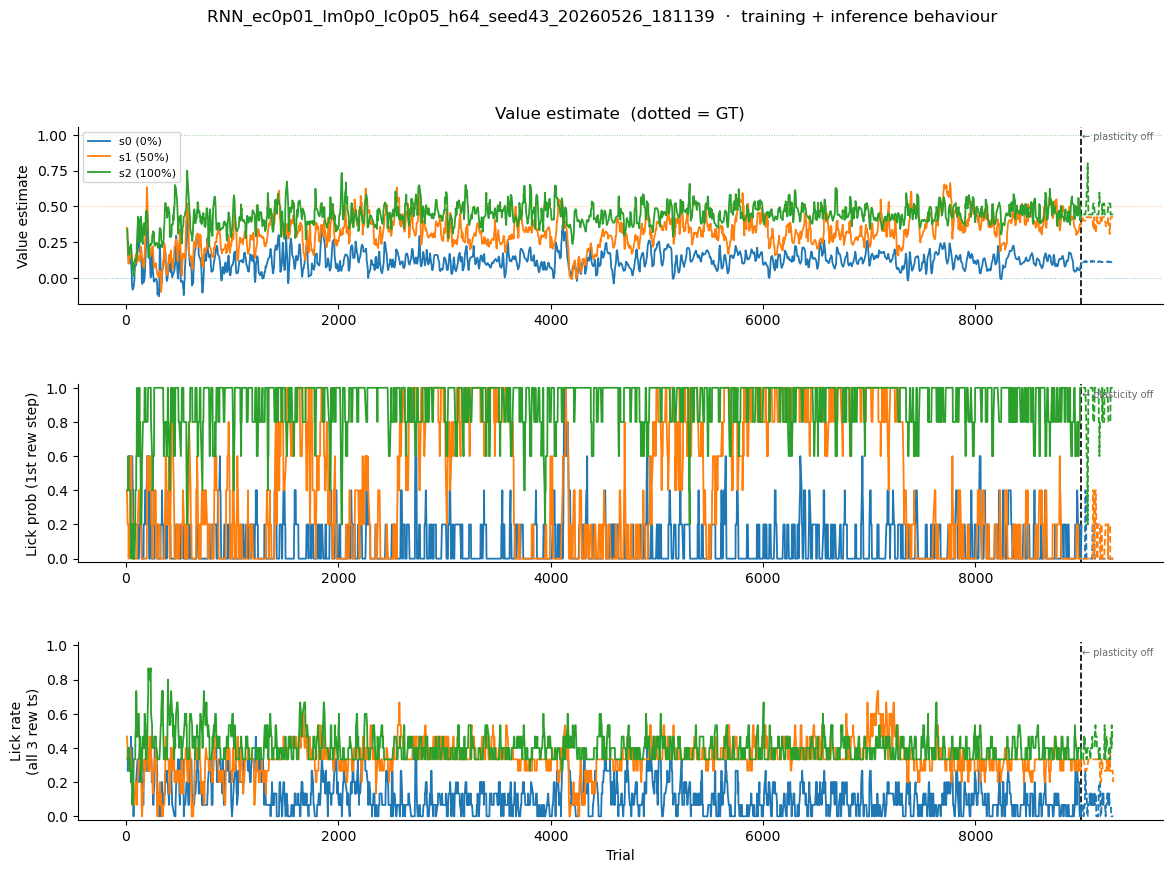

In [249]:
smooth_w = max(1, min(5, len(all_trial_data) // 20))

train_td = np.array([
    (d["global_trial"], d["context"], d["stimulus"],
     d["reward_available"], d["licked"], d["value_estimate"], d["lick_count"])
    for d in all_trial_data
], dtype=float)

infer_td = np.array([
    (d["global_trial"], d["context"], d["stimulus"],
     d["reward_available"], d["licked"], d["value_estimate"], d["lick_count"])
    for d in infer_trial_data
], dtype=float)

n_train = len(all_trial_data)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), gridspec_kw={"hspace": 0.45})

for ax in axes:
    ax.axvline(n_train - 0.5, color="black", lw=1.2, linestyle="--")
    ax.text(n_train + 0.5, 0.97, "← plasticity off",
            transform=ax.get_xaxis_transform(), fontsize=7, ha="left", va="top", color="dimgray")

for si in range(n_stimuli):
    c = stim_colors[si % len(stim_colors)]
    for td, ls in [(train_td, "-"), (infer_td, "--")]:
        m = td[:, 2] == si
        xi = td[m, 0].astype(int)
        v, lp, lr = td[m, 5], td[m, 4], td[m, 6] / reward_timesteps
        def _sm(y):
            if smooth_w > 1 and len(y) >= smooth_w:
                s = np.convolve(y, np.ones(smooth_w)/smooth_w, mode="valid")
                return xi[smooth_w-1:], s
            return xi, y
        xx, sv  = _sm(v)
        xx, slp = _sm(lp)
        xx, slr = _sm(lr)
        axes[0].plot(xx, sv,  color=c, lw=1.3, ls=ls, label=stimuli[si] if ls=="-" else None)
        axes[1].plot(xx, slp, color=c, lw=1.3, ls=ls)
        axes[2].plot(xx, slr, color=c, lw=1.3, ls=ls)

for si in range(n_stimuli):
    for ci in range(n_contexts):
        axes[0].axhline(value_matrix[si, ci], color=stim_colors[si%len(stim_colors)],
                        lw=0.7, linestyle=":", alpha=0.5)

axes[0].set_ylabel("Value estimate"); axes[0].set_title("Value estimate  (dotted = GT)")
axes[0].legend(fontsize=8)
axes[1].set_ylabel("Lick prob (1st rew step)"); axes[1].set_ylim(-0.02, 1.02)
axes[2].set_ylabel(f"Lick rate\n(all {reward_timesteps} rew ts)"); axes[2].set_ylim(-0.02, 1.02)
axes[2].set_xlabel("Trial")

fig.suptitle(f"{RUN_ID}  ·  training + inference behaviour", y=1.01)
plt.tight_layout()
save_run_fig(fig, "fig1_behaviour.png")
plt.show()

## § 2 — Policy Similarity Analysis (PSA)

PSA (threshold=0.25):
  c0: high=0.910  mid=0.100  low=0.030  score=0.940  delta=0.880


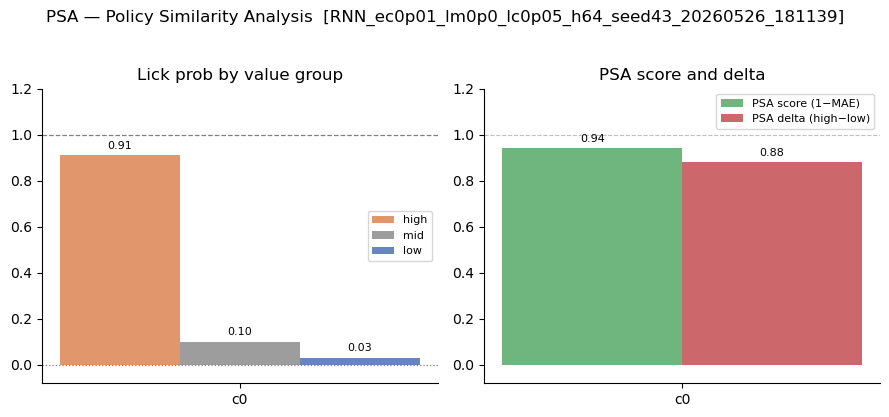

In [237]:
_psa_threshold = 0.25
psa = policy_similarity_analysis(lick_sc, value_matrix, threshold=_psa_threshold)

print(f"PSA (threshold={_psa_threshold}):")
for ci in range(n_contexts):
    r = psa[ci]
    print(f"  {contexts[ci]}: high={r['high_lick']:.3f}  mid={r['mid_lick']:.3f}  "
          f"low={r['low_lick']:.3f}  score={r['psa_score']:.3f}  delta={r['psa_delta']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

ax = axes[0]
grp_col = {"high": "#DD8452", "mid": "#8C8C8C", "low": "#4C72B0"}
x_ctx  = np.arange(n_contexts)
width  = 0.22
for i, (key, col) in enumerate(grp_col.items()):
    vals = [psa[ci][f"{key}_lick"] for ci in range(n_contexts)]
    bars = ax.bar(x_ctx + (i-1)*width, vals, width=width, color=col, alpha=0.85, label=key)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.02, f"{val:.2f}",
                    ha="center", va="bottom", fontsize=8)
ax.axhline(1.0, color="black", lw=0.9, ls="--", alpha=0.5)
ax.axhline(0.0, color="black", lw=0.9, ls=":",  alpha=0.5)
ax.set_xticks(x_ctx); ax.set_xticklabels(contexts)
ax.set_ylim(-0.08, 1.2)
ax.set_title("Lick prob by value group")
ax.legend(fontsize=8)

ax = axes[1]
w2 = 0.35
bars_s = ax.bar(x_ctx - w2/2, [psa[ci]["psa_score"] for ci in range(n_contexts)],
                width=w2, color="#55A868", alpha=0.85, label="PSA score (1−MAE)")
bars_d = ax.bar(x_ctx + w2/2, [psa[ci]["psa_delta"] for ci in range(n_contexts)],
                width=w2, color="#C44E52", alpha=0.85, label="PSA delta (high−low)")
for bar in list(bars_s) + list(bars_d):
    v = bar.get_height()
    if not np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8)
ax.axhline(1, color="gray", lw=0.8, ls="--", alpha=0.5)
ax.set_xticks(x_ctx); ax.set_xticklabels(contexts)
ax.set_ylim(-0.08, 1.2)
ax.set_title("PSA score and delta")
ax.legend(fontsize=8)

fig.suptitle(f"PSA — Policy Similarity Analysis  [{RUN_ID}]", y=1.03)
plt.tight_layout()
save_run_fig(fig, "fig2_psa.png")
plt.show()

## § 3 — Neuron selectivity and value preference

KeyboardInterrupt: 

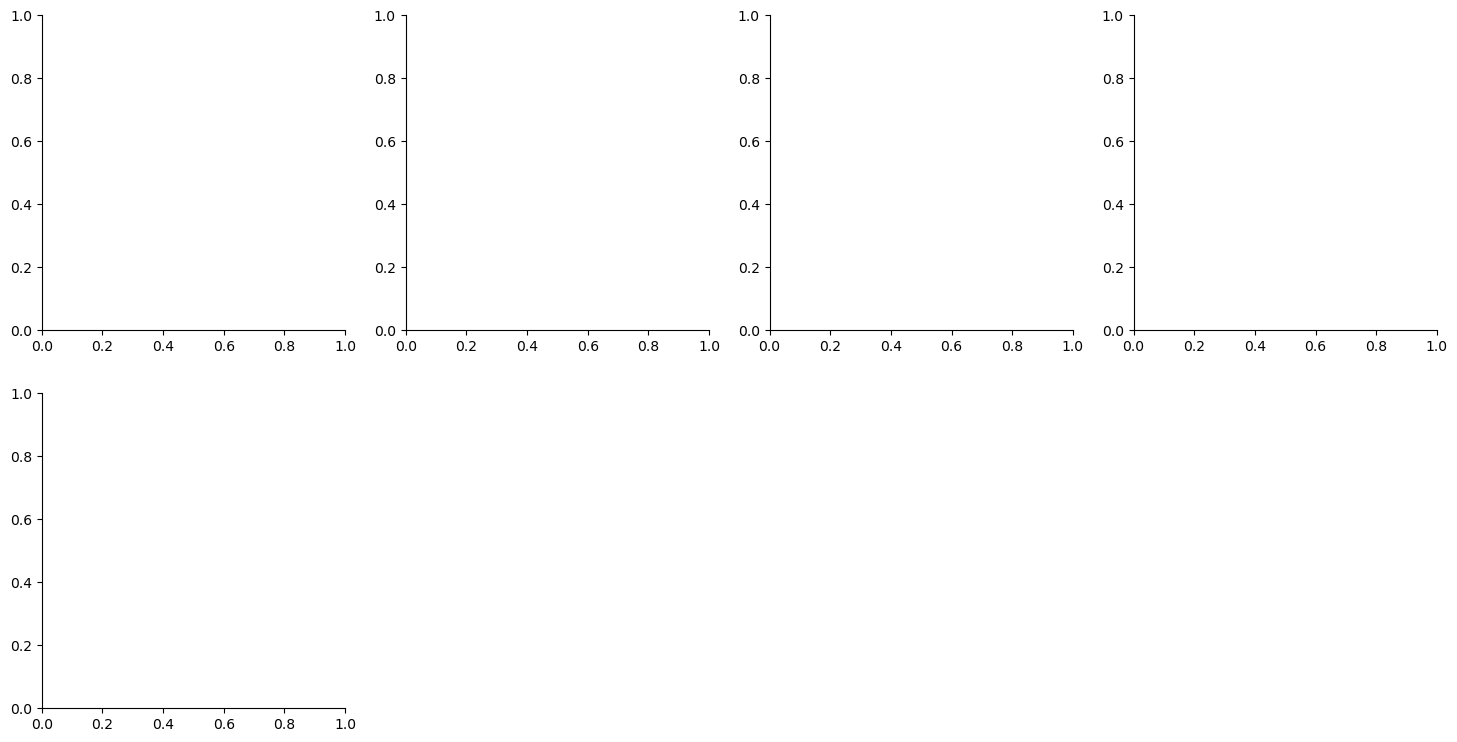

In [238]:
si_threshold   = 0.1
silent_thr     = 1e-4   # cogNN-style silent mask

tuning  = compute_unit_tuning(infer_act, period="stim")
n_units = tuning.shape[0]

# Three SI variants
si_peak  = selectivity_index(tuning)               # 1 − mean/max
si_conc  = selectivity_index_concentration(tuning)  # max/sum
si_range = selectivity_index_range(tuning)          # (max−min)/Σ|r|  [cogNN]

props_peak,  _ = preferred_stim_proportions(tuning, si_threshold=si_threshold, si_values=si_peak)
props_conc,  _ = preferred_stim_proportions(tuning, si_threshold=si_threshold, si_values=si_conc)
props_range, _ = preferred_stim_proportions(tuning, si_threshold=si_threshold, si_values=si_range,
                                             silent_threshold=silent_thr)

n_sel_peak  = int((si_peak  >= si_threshold).sum())
n_sel_conc  = int((si_conc  >= si_threshold).sum())
mean_ctx    = np.nanmean(tuning, axis=2)
max_abs     = np.nanmax(np.abs(mean_ctx), axis=1)
n_sel_range = int(((si_range >= si_threshold) & (max_abs >= silent_thr)).sum())

# Sort units by preferred stim then SI for the heatmap
pref_stim = np.nanargmax(mean_ctx, axis=1)
sort_idx  = np.lexsort((si_peak, pref_stim))
tuning_s  = mean_ctx[sort_idx]
u_mean    = np.nanmean(tuning_s, axis=1, keepdims=True)
u_std     = np.nanstd(tuning_s,  axis=1, keepdims=True); u_std[u_std == 0] = 1.0
tuning_z  = (tuning_s - u_mean) / u_std

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# ── Row 0: tuning heatmap + SI histograms ──────────────────────────────────────
im = axes[0, 0].imshow(tuning_z, aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5)
axes[0, 0].set_xticks(range(n_stimuli)); axes[0, 0].set_xticklabels(stimuli, fontsize=7)
axes[0, 0].set_xlabel("Stimulus")
axes[0, 0].set_ylabel(f"Unit (sorted by preferred stim, n={n_units})")
axes[0, 0].set_title("Stimulus tuning  (z-scored, stim period)")
plt.colorbar(im, ax=axes[0, 0], shrink=0.6)

ax = axes[0, 1]
ax.hist(si_peak, bins=25, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(si_threshold, color="crimson", lw=1.5, ls="--", label=f"threshold={si_threshold}")
ax.set_xlabel(f"SI = 1−mean/max  (max={1-1/n_stimuli:.2f})")
ax.set_ylabel("# units"); ax.set_title(f"1−mean/max  ({n_sel_peak}/{n_units} sel)")
ax.legend(fontsize=8)

ax = axes[0, 2]
ax.hist(si_conc, bins=25, color="darkorange", edgecolor="white", alpha=0.85)
ax.axvline(si_threshold, color="crimson", lw=1.5, ls="--", label=f"threshold={si_threshold}")
ax.axvline(1/n_stimuli, color="gray", lw=1, ls=":", alpha=0.7,
           label=f"flat = 1/{n_stimuli}={1/n_stimuli:.2f}")
ax.set_xlabel("SI = max/sum")
ax.set_ylabel("# units"); ax.set_title(f"max/sum  ({n_sel_conc}/{n_units} sel)")
ax.legend(fontsize=8)

ax = axes[0, 3]
ax.hist(si_range, bins=25, color="mediumseagreen", edgecolor="white", alpha=0.85)
ax.axvline(si_threshold, color="crimson", lw=1.5, ls="--", label=f"threshold={si_threshold}")
ax.set_xlabel("SI = (max−min)/Σ|r|  [cogNN]")
ax.set_ylabel("# units")
ax.set_title(f"range/|sum| + silent≥{silent_thr}  ({n_sel_range}/{n_units} sel)")
ax.legend(fontsize=8)

# ── Row 1: preferred stimulus breakdown (one panel per SI variant) ─────────────
ci = 0
for col, (props, si_label, n_sel) in enumerate([
    (props_peak,  "1−mean/max",    n_sel_peak),
    (props_conc,  "max/sum",       n_sel_conc),
    (props_range, "range/|sum|",   n_sel_range),
]):
    ax = axes[1, col + 1]
    fracs = props[ci]["frac_per_stim"] * 100
    bars  = ax.bar(range(n_stimuli), fracs,
                   color=[stim_colors[si % len(stim_colors)] for si in range(n_stimuli)],
                   alpha=0.85, edgecolor="white")
    for xi, v in enumerate(fracs):
        if not np.isnan(v):
            ax.text(xi, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(n_stimuli)); ax.set_xticklabels(stimuli, fontsize=8)
    ax.set_ylabel("% of selective neurons")
    ax.set_ylim(0, 110)
    ax.set_title(f"Preferred stim  (SI={si_label})\n"
                 f"n_sel={n_sel} / {n_units}")
    ax.set_xlabel("Stimulus")

# Scatter: SI_peak vs SI_range, coloured by preferred stim
ax = axes[1, 0]
_sc = [stim_colors[s % len(stim_colors)] for s in pref_stim]
ax.scatter(si_peak, si_range, c=_sc, s=20, alpha=0.6)
ax.axvline(si_threshold, color="crimson", lw=1, ls="--", alpha=0.7)
ax.axhline(si_threshold, color="crimson", lw=1, ls="--", alpha=0.7, label=f"threshold={si_threshold}")
handles = [Patch(color=stim_colors[si % len(stim_colors)], label=stimuli[si])
           for si in range(n_stimuli)]
ax.legend(handles=handles, fontsize=7, frameon=False, title="Preferred stim")
ax.set_xlabel("SI: 1−mean/max")
ax.set_ylabel("SI: range/|sum|  [cogNN]")
ax.set_title("SI comparison (colour = preferred stimulus)")

fig.suptitle(f"Unit selectivity  [{RUN_ID}]\n"
             "bar height = % of selective neurons whose peak response is to that stimulus",
             y=1.01)
plt.tight_layout()
save_run_fig(fig, "fig3_selectivity.png")
plt.show()

In [ ]:
# ── Readout vs non-readout population selectivity ─────────────────────────────
_rf   = vd.get("readout_fraction", 1.0)
_n_ro = max(1, int(n_units * _rf))
n_nro = n_units - _n_ro

if _rf >= 1.0 or n_nro == 0:
    print(f"readout_fraction={_rf:.2f} — full readout, no split to show.")
else:
    tuning_ro  = tuning[:_n_ro]   # (n_ro, n_stim, n_ctx)
    tuning_nro = tuning[_n_ro:]   # (n_nro, n_stim, n_ctx)

    _si_ro  = selectivity_index_range(tuning_ro)
    _si_nro = selectivity_index_range(tuning_nro)

    _mean_ro  = np.nanmean(tuning_ro,  axis=2)
    _mean_nro = np.nanmean(tuning_nro, axis=2)
    _max_ro   = np.nanmax(np.abs(_mean_ro),  axis=1)
    _max_nro  = np.nanmax(np.abs(_mean_nro), axis=1)

    _props_ro,  _ = preferred_stim_proportions(tuning_ro,  si_threshold=si_threshold,
                                                si_values=_si_ro,  silent_threshold=silent_thr)
    _props_nro, _ = preferred_stim_proportions(tuning_nro, si_threshold=si_threshold,
                                                si_values=_si_nro, silent_threshold=silent_thr)

    _n_sel_ro  = int(((  _si_ro  >= si_threshold) & (_max_ro  >= silent_thr)).sum())
    _n_sel_nro = int((( _si_nro  >= si_threshold) & (_max_nro >= silent_thr)).sum())

    _pop_data = [
        ("Readout",     _si_ro,  _props_ro,  _n_ro,  _n_sel_ro,  _max_ro,  "steelblue"),
        ("Non-readout", _si_nro, _props_nro, n_nro,  _n_sel_nro, _max_nro, "coral"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for row, (pop_label, _si_p, _props_p, _n_p, _n_sel_p, _max_p, _col) in enumerate(_pop_data):
        # SI histogram
        ax = axes[row, 0]
        _active = _si_p[_max_p >= silent_thr]
        ax.hist(_active[~np.isnan(_active)], bins=20, color=_col, edgecolor="white", alpha=0.85)
        ax.axvline(si_threshold, color="crimson", lw=1.5, ls="--",
                   label=f"threshold={si_threshold}")
        ax.set_xlabel("SI = range/|sum|  (cogNN)")
        ax.set_ylabel("# units")
        ax.set_title(f"{pop_label} neurons (n={_n_p})\n{_n_sel_p} selective")
        ax.legend(fontsize=8)

        # Preferred-stim bar chart
        ax = axes[row, 1]
        _fracs = _props_p[0]["frac_per_stim"] * 100
        ax.bar(range(n_stimuli), _fracs,
               color=[stim_colors[si % len(stim_colors)] for si in range(n_stimuli)],
               alpha=0.85, edgecolor="white")
        for xi, v in enumerate(_fracs):
            if not np.isnan(v):
                ax.text(xi, v + 1.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(range(n_stimuli))
        ax.set_xticklabels(stimuli, fontsize=8)
        ax.set_ylabel("% of selective neurons")
        ax.set_ylim(0, 115)
        ax.axhline(100 / n_stimuli, color="gray", lw=1, ls="--", alpha=0.5, label="uniform")
        ax.set_title(f"{pop_label}: preferred stimulus\nn_sel={_n_sel_p}/{_n_p}")
        ax.legend(fontsize=8)

    fig.suptitle(
        f"Readout vs non-readout selectivity  [{RUN_ID}]\n"
        f"readout_fraction={_rf:.2f}  \u00b7  first {_n_ro} neurons \u2192 heads, "
        f"last {n_nro} are non-readout\n"
        f"SI = range/|sum|  \u00b7  threshold={si_threshold}  \u00b7  silent_thr={silent_thr}",
        y=1.02,
    )
    plt.tight_layout()
    save_run_fig(fig, "fig3b_readout_vs_nonreadout_selectivity.png")
    plt.show()


In [ ]:
# ── All-neuron preferred stimulus ───────────────────────────────────────────
_si_all  = selectivity_index_range(tuning)
_mean_all = np.nanmean(tuning, axis=2)
_max_all  = np.nanmax(np.abs(_mean_all), axis=1)
_n_sel_all = int(((_si_all >= si_threshold) & (_max_all >= silent_thr)).sum())
_props_all, _ = preferred_stim_proportions(
    tuning, si_threshold=si_threshold,
    si_values=_si_all, silent_threshold=silent_thr)

fig, ax = plt.subplots(figsize=(max(4, n_stimuli * 0.9 + 1.5), 3.5))
_fracs_all = _props_all[0]["frac_per_stim"] * 100
ax.bar(range(n_stimuli), _fracs_all,
       color=[stim_colors[si % len(stim_colors)] for si in range(n_stimuli)],
       alpha=0.85, edgecolor="white")
for xi, v in enumerate(_fracs_all):
    if not np.isnan(v):
        ax.text(xi, v + 1.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(n_stimuli))
ax.set_xticklabels(stimuli, fontsize=9)
ax.set_ylabel("% of selective neurons")
ax.set_ylim(0, 115)
ax.axhline(100 / n_stimuli, color="gray", lw=1, ls="--", alpha=0.5, label="uniform")
ax.legend(fontsize=8)
ax.set_title(
    f"All neurons: preferred stimulus  [{RUN_ID}]\n"
    f"n_selective={_n_sel_all}/{n_units}  "
    f"SI threshold={si_threshold}  silent_thr={silent_thr}",
    fontsize=9)
plt.tight_layout()
save_run_fig(fig, "fig_preferred_stim_all.png")
plt.show()

In [ ]:
# ── Lick probability per stimulus — trained model (inference trials) ─────────
_lick_by_stim   = np.array([inf_lick[inf_stim == si].mean()   for si in range(n_stimuli)])
_ravail_by_stim = np.array([inf_ravail[inf_stim == si].mean() for si in range(n_stimuli)])

fig, ax = plt.subplots(figsize=(max(4, n_stimuli * 0.9 + 1.5), 3.5))
ax.bar(range(n_stimuli), _lick_by_stim * 100,
       color=[stim_colors[si % len(stim_colors)] for si in range(n_stimuli)],
       alpha=0.85, edgecolor="white")
for xi, v in enumerate(_lick_by_stim * 100):
    ax.text(xi, v + 1.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(n_stimuli))
ax.set_xticklabels(stimuli, fontsize=9)
ax.set_ylabel("Lick probability (%)")
ax.set_ylim(0, 115)
ax.set_title(
    f"Lick probability per stimulus — trained model  [{RUN_ID}]\n"
    f"inference trials (plasticity off)  n={len(inf_lick)} trials",
    fontsize=9)
plt.tight_layout()
save_run_fig(fig, "fig_lick_prob_per_stim.png")
plt.show()

In [ ]:
# ── Diagnostic: are s0-preferring neurons excitatory or suppression neurons? ──
# After mean-centering, argmax can't distinguish:
#   excitatory:   [s0=+0.5, s1=+0.2, s2=+0.1]  — genuinely excited by s0
#   suppression:  [s0=-0.1, s1=-0.5, s2=-0.9]  — suppressed by all, least by s0
# This cell checks the sign of raw (uncentered) tuning for each preferred-stim group.

mean_ctx_raw = np.nanmean(tuning, axis=2)   # (n_units, n_stim) — raw, uncentered
max_abs      = np.nanmax(np.abs(mean_ctx_raw), axis=1)
silent_mask  = max_abs < silent_thr

# Use range SI + silent mask for grouping (most conservative = closest to cogNN)
sel_range = (si_range >= si_threshold) & ~silent_mask
mean_ctx_c = mean_ctx_raw - np.nanmean(mean_ctx_raw, axis=1, keepdims=True)
pref_r     = np.nanargmax(mean_ctx_c, axis=1)   # preferred stim (mean-centred)

fig, axes = plt.subplots(2, n_stimuli, figsize=(5 * n_stimuli, 7),
                          gridspec_kw={"hspace": 0.45})

for si in range(n_stimuli):
    mask = sel_range & (pref_r == si)
    n    = int(mask.sum())

    # Row 0: distribution of raw activation at each stimulus for this preferred-stim group
    ax = axes[0, si]
    for sj in range(n_stimuli):
        vals = mean_ctx_raw[mask, sj]
        ax.hist(vals, bins=20, alpha=0.6, label=stimuli[sj],
                color=stim_colors[sj % len(stim_colors)], edgecolor="none")
    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.6)
    ax.set_xlabel("Raw mean activation")
    ax.set_ylabel("# neurons")
    ax.set_title(f"Prefers {stimuli[si]}  (n={n})\nActivation distribution per stimulus")
    ax.legend(fontsize=7, frameon=False)

    # Row 1: mean tuning curve ± SEM for this group
    ax = axes[1, si]
    if n > 0:
        tc   = mean_ctx_raw[mask]                  # (n, n_stim)
        m    = tc.mean(0)
        sem  = tc.std(0) / np.sqrt(n)
        ax.bar(range(n_stimuli), m,
               color=[stim_colors[sj % len(stim_colors)] for sj in range(n_stimuli)],
               alpha=0.8, edgecolor="white")
        ax.errorbar(range(n_stimuli), m, yerr=sem,
                    fmt="none", color="black", capsize=4, lw=1.2)
        # Mark which is the preferred stimulus
        ax.scatter([si], [m[si]], marker="*", s=150, color="crimson", zorder=5,
                   label="preferred")
        n_pos = int((m > 0).sum())
        ax.set_title(f"Mean tuning curve  ({n_pos}/{n_stimuli} stim have +ve mean)")
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xticks(range(n_stimuli)); ax.set_xticklabels(stimuli, fontsize=8)
    ax.set_xlabel("Stimulus"); ax.set_ylabel("Mean activation")
    ax.legend(fontsize=7, frameon=False)

# Summary: fraction with positive s0-activation, per preferred-stim group
print("Raw activation sign breakdown (range SI + silent mask):")
for si in range(n_stimuli):
    mask = sel_range & (pref_r == si)
    n    = int(mask.sum())
    if n == 0:
        print(f"  Prefers {stimuli[si]}: 0 neurons")
        continue
    n_pos = int((mean_ctx_raw[mask, si] > 0).sum())   # positive activation at preferred stim
    n_neg = n - n_pos
    print(f"  Prefers {stimuli[si]}  (n={n}): "
          f"{n_pos} excitatory (+ve at preferred stim)  |  {n_neg} suppression (-ve at preferred stim)")

fig.suptitle(
    f"Are preferred-stim neurons excitatory or suppression neurons?  [{RUN_ID}]\n"
    f"SI = range/|sum|  ≥ {si_threshold}  +  silent mask ≥ {silent_thr}\n"
    "★ = preferred stimulus  |  dashed line = 0",
    y=1.01, fontsize=9,
)
plt.tight_layout()
save_run_fig(fig, "fig3b_preferred_stim_sign.png")
plt.show()

In [ ]:
# ── Trial-aligned activation heatmap (ITI tail + stim + reward) ───────────────
_iti_tail = 3   # ITI timesteps shown before stim onset

_ts     = infer_act["trial_structure"]
_hs     = infer_act["hidden_states"]     # (T, H)
_stim_a = infer_act["stimulus"]
_ravail  = infer_act["reward_available"]

_stim_len = _ts[0]["stim_window"][1]  - _ts[0]["stim_window"][0]
_rew_len  = _ts[0]["reward_window"][1] - _ts[0]["reward_window"][0]
_win_len  = _iti_tail + _stim_len + _rew_len

_x_labels = (
    [f"ITI-{_iti_tail - i}" for i in range(_iti_tail)]
    + [f"S{t+1}" for t in range(_stim_len)]
    + [f"O{t+1}" for t in range(_rew_len)]
)
_tick_pos = sorted({0, _iti_tail - 1, _iti_tail, _iti_tail + _stim_len - 1,
                    _iti_tail + _stim_len, _win_len - 1})
_tick_pos = [p for p in _tick_pos if 0 <= p < _win_len]

def _collect_snippets(mask):
    snippets = []
    for _ti, _tr in enumerate(_ts):
        if not mask[_ti]:
            continue
        _ss = _tr["stim_window"][0]
        _se = _tr["stim_window"][1]
        _rs = _tr["reward_window"][0]
        _re = _tr["reward_window"][1]
        _iti_s = max(0, _ss - _iti_tail)
        _pad   = _iti_tail - (_ss - _iti_s)
        _chunk = np.concatenate([
            np.zeros((_pad, _hs.shape[1])),
            _hs[_iti_s:_se],
            _hs[_rs:_re],
        ], axis=0)
        snippets.append(_chunk[:_win_len])
    return np.stack(snippets) if snippets else None   # (n_trials, T, H)

# Build conditions: one per stim; mid stim split by reward availability
_conditions = []
for _si in range(n_stimuli):
    _snips = _collect_snippets(_stim_a == _si)
    if _snips is not None:
        _conditions.append((stimuli[_si], _snips))

# Shared colour scale
_all_means = np.concatenate([_s.mean(axis=0) for _, _s in _conditions], axis=0)
_vmax = float(np.percentile(_all_means, 99))

_n_conds = len(_conditions)
fig, _axes_all = plt.subplots(
    2, _n_conds + 1,
    figsize=(3.5 * _n_conds + 0.5, 9),
    gridspec_kw={"height_ratios": [4, 1.5],
                 "width_ratios": [1.0] * _n_conds + [0.04]},
    sharex="col",
)
if _n_conds == 1:
    _axes_all = _axes_all.reshape(2, -1)
axes      = _axes_all[:, :_n_conds]
_cbar_ax  = _axes_all[0, _n_conds]
_axes_all[1, _n_conds].set_visible(False)

# Shared y-limits for population average row
_pop_avgs = [_s.mean(axis=(0, 2)) for _, _s in _conditions]   # (n_conds, T)
_ymax_pop = (np.nanmax(np.concatenate([a for a in _pop_avgs])) * 1.15
            if any(np.isfinite(a).any() for a in _pop_avgs) else 1.0)

_im = None
for col, (_label, _snips) in enumerate(_conditions):
    _ax_h = axes[0, col]
    _ax_p = axes[1, col]

    # ── heatmap ──────────────────────────────────────────────────────
    _mean_sorted = _snips.mean(axis=0)[:, sort_idx].T   # (H_sorted, T)
    _im = _ax_h.imshow(_mean_sorted, aspect="auto", cmap="hot",
                       vmin=0, vmax=_vmax, interpolation="nearest")
    _ax_h.set_title(f"{_label}\n(n={len(_snips)})", fontsize=9)
    _ax_h.axvline(_iti_tail - 0.5, color="white", lw=1.2, ls="--", alpha=0.6)
    _ax_h.axvline(_iti_tail + _stim_len - 0.5, color="white", lw=1.2, ls="--", alpha=0.6)
    _ax_h.set_xticks([])   # shared with pop-avg panel below
    if col == 0:
        _ax_h.set_ylabel(f"Unit (sorted, n={n_units})", fontsize=8)
    else:
        _ax_h.set_ylabel("")

    # ── population average ────────────────────────────────────────────
    _pop = _snips.mean(axis=(0, 2))   # mean over trials and units → (T,)
    _ax_p.plot(range(_win_len), _pop, color=stim_colors[col % len(stim_colors)], lw=1.5)
    _ax_p.axvline(_iti_tail - 0.5, color="gray", lw=1, ls="--", alpha=0.6)
    _ax_p.axvline(_iti_tail + _stim_len - 0.5, color="gray", lw=1, ls="--", alpha=0.6)
    _ax_p.set_xlim(-0.5, _win_len - 0.5)
    _ax_p.set_ylim(0, _ymax_pop)
    _ax_p.set_xticks(_tick_pos)
    _ax_p.set_xticklabels([_x_labels[p] for p in _tick_pos], fontsize=7, rotation=45)
    _ax_p.set_xlabel("Time (within trial)", fontsize=8)
    if col == 0:
        _ax_p.set_ylabel("Pop. avg\nactivation", fontsize=7)
    else:
        _ax_p.set_ylabel("")
    _ax_p.tick_params(labelsize=7)

plt.colorbar(_im, cax=_cbar_ax, label="Mean activation")
_cbar_ax.tick_params(labelsize=7)
fig.suptitle(f"Trial-aligned mean activations  [{RUN_ID}]\n"
             f"ITI tail = {_iti_tail} ts  |  stim = {_stim_len} ts  |  "
             f"reward = {_rew_len} ts",
             fontsize=10)
plt.tight_layout()
save_run_fig(fig, "fig3b_trial_aligned_activations.png")
plt.show()


In [ ]:
# ── Untrained model comparison (same conditions, random-init weights) ─────────
# Requires model_init.pt saved alongside model.pt (needs a rerun if missing).
_init_path = RUN_DIR / "model_init.pt"
if not _init_path.exists():
    print("model_init.pt not found — rerun the sweep script to generate it")
else:
    _readout_frac = vd.get("readout_fraction", 1.0)
    _obs_dim = vd.get("obs_dim", None)
    if _obs_dim is None:
        _sd = torch.load(_init_path, map_location="cpu")
        _obs_dim = _sd["backbone.input2h.weight"].shape[1]
    _bb_init  = RNN(input_size=_obs_dim, hidden_size=hidden_size, output_size=1)
    _ac_init  = ActorCritic(backbone=_bb_init, num_actions=2,
                            readout_fraction=_readout_frac)
    _ac_init.load_state_dict(torch.load(_init_path, map_location="cpu"))
    _ac_init.eval()

    _infer_states = vd.get("infer_states", None)
    _infer_ravail = vd.get("infer_reward_availability", None)
    _infer_struct = infer_act["trial_structure"]

    if _infer_states is None or _infer_ravail is None:
        print("infer_states / infer_reward_availability not in vis_data — "
              "add them to the sweep script and rerun")
    else:
        _env_kwargs = {k: vd[k] for k in
                      ("reward_lick", "reward_no_lick", "reward_lick_fa",
                       "lick_cost") if k in vd}
        _env_init = TaskEnv(states=_infer_states, reward_availability=_infer_ravail,
                            **_env_kwargs)
        _obs, _ = _env_init.reset()
        _h = None
        _hs_init = []
        with torch.no_grad():
            done = False
            while not done:
                _ot = torch.tensor(_obs, dtype=torch.float32).unsqueeze(0)
                _, _, _h = _ac_init.step(_ot, _h)
                _hs_init.append(np.array(_h.squeeze(0).cpu().tolist(), dtype=np.float32))
                _a = _ac_init.make_dist(
                    _ac_init.policy_head(_h[..., :_ac_init.n_readout])
                ).sample().item()
                _obs, _, done, _, _ = _env_init.step(_a)
        _hs_init_np = np.array(_hs_init)   # (T, H)

        def _collect_init(mask):
            snippets = []
            for _ti, _tr in enumerate(_infer_struct):
                if not mask[_ti]:
                    continue
                _ss, _se = _tr["stim_window"]
                _rs, _re = _tr["reward_window"]
                _iti_s = max(0, _ss - _iti_tail)
                _pad   = _iti_tail - (_ss - _iti_s)
                _chunk = np.concatenate([
                    np.zeros((_pad, _hs_init_np.shape[1])),
                    _hs_init_np[_iti_s:_se],
                    _hs_init_np[_rs:_re],
                ], axis=0)
                snippets.append(_chunk[:_win_len])
            return np.stack(snippets) if snippets else None

        _stim_a_i = infer_act["stimulus"]
        _conds_init = [(stimuli[_si], _collect_init(_stim_a_i == _si))
                       for _si in range(n_stimuli)]
        _conds_init = [c for c in _conds_init if c[1] is not None]

        _all_init = np.concatenate([s.mean(axis=0) for _, s in _conds_init], axis=0)
        _vmax_init = float(np.percentile(_all_init, 99)) if np.isfinite(_all_init).any() else 1.0
        _ymax_init = (max(s.mean(axis=(0, 2)).max() for _, s in _conds_init) * 1.15
                      if _conds_init else 1.0)

        _nc_init = len(_conds_init)
        # Dedicated colorbar column — keeps all panel widths equal so sharex aligns
        fig, _axes_all_init = plt.subplots(
            2, _nc_init + 1,
            figsize=(3.5 * _nc_init + 0.5, 9),
            gridspec_kw={"height_ratios": [4, 1.5],
                         "width_ratios": [1.0] * _nc_init + [0.04]},
            sharex="col",
        )
        if _nc_init == 1:
            _axes_all_init = _axes_all_init.reshape(2, -1)
        _axes_init   = _axes_all_init[:, :_nc_init]
        _cbar_ax_init = _axes_all_init[0, _nc_init]
        _axes_all_init[1, _nc_init].set_visible(False)

        _im = None
        for _col, (_lbl, _snips) in enumerate(_conds_init):
            _ax_h, _ax_p = _axes_init[0, _col], _axes_init[1, _col]
            _ms = _snips.mean(axis=0)[:, sort_idx].T
            _im = _ax_h.imshow(_ms, aspect="auto", cmap="hot",
                               vmin=0, vmax=_vmax_init, interpolation="nearest")
            _ax_h.set_title(f"{_lbl}\n(n={len(_snips)})", fontsize=9)
            _ax_h.axvline(_iti_tail - 0.5, color="white", lw=1.2, ls="--", alpha=0.6)
            _ax_h.axvline(_iti_tail + _stim_len - 0.5, color="white", lw=1.2, ls="--", alpha=0.6)
            _ax_h.set_xlim(-0.5, _win_len - 0.5)
            if _col == 0:
                _ax_h.set_ylabel(f"Unit (sorted by pref stim, n={n_units})", fontsize=8)
            _pop = _snips.mean(axis=(0, 2))
            _ax_p.plot(range(_win_len), _pop,
                       color=stim_colors[_col % len(stim_colors)], lw=1.5)
            _ax_p.axvline(_iti_tail - 0.5, color="gray", lw=1, ls="--", alpha=0.6)
            _ax_p.axvline(_iti_tail + _stim_len - 0.5, color="gray", lw=1, ls="--", alpha=0.6)
            _ax_p.set_ylim(0, _ymax_init)
            _ax_p.set_xticks(_tick_pos)
            _ax_p.set_xticklabels([_x_labels[p] for p in _tick_pos], fontsize=7, rotation=45)
            _ax_p.set_xlabel("Time (within trial)", fontsize=8)
            if _col == 0:
                _ax_p.set_ylabel("Pop. avg\nactivation", fontsize=7)
            _ax_p.tick_params(labelsize=7)

        plt.colorbar(_im, cax=_cbar_ax_init, label="Mean activation")
        _cbar_ax_init.tick_params(labelsize=7)
        fig.suptitle(f"Trial-aligned activations — UNTRAINED model  [{RUN_ID}]",
                     fontsize=10)
        plt.tight_layout()
        save_run_fig(fig, "fig3b_untrained_trial_aligned.png")
        plt.show()


In [ ]:
# ── Population activity over training (checkpoint-based) ─────────────────────
# Requires checkpoints/ directory produced by the sweep script (needs rerun).
# For each checkpoint, runs inference on the same infer_states and computes
# mean population activity during ITI tail, stim, and reward periods.

_ckpt_dir = RUN_DIR / "checkpoints"
_ckpt_files = sorted(_ckpt_dir.glob("checkpoint_*.pt")) if _ckpt_dir.exists() else []

if not _ckpt_files:
    print("No checkpoints found — rerun the sweep script to generate them")
else:
    _infer_states = vd.get("infer_states")
    _infer_ravail = vd.get("infer_reward_availability")
    _infer_struct = infer_act["trial_structure"]
    _readout_frac = vd.get("readout_fraction", 1.0)

    if _infer_states is None:
        print("infer_states not in vis_data — rerun sweep script")
    else:
        # Reconstruct obs_dim from first checkpoint
        _sd0   = torch.load(_ckpt_files[0], map_location="cpu")
        _obs_d = _sd0["backbone.input2h.weight"].shape[1]

        from cxval.envs import TaskEnv
        _env_kw = {k: vd[k] for k in
                   ("reward_lick", "reward_miss", "reward_lick_fa", "lick_cost")
                   if k in vd}

        def _run_ckpt_inference(state_dict):
            _bb = RNN(input_size=_obs_d, hidden_size=hidden_size, output_size=1)
            _ac = ActorCritic(backbone=_bb, num_actions=2,
                              readout_fraction=_readout_frac)
            _ac.load_state_dict(state_dict)
            _ac.eval()
            _env = TaskEnv(states=_infer_states,
                           reward_availability=_infer_ravail, **_env_kw)
            _obs, _ = _env.reset()
            _h, _hs = None, []
            with torch.no_grad():
                _done = False
                while not _done:
                    _ot = torch.tensor(_obs, dtype=torch.float32).unsqueeze(0)
                    _, _, _h = _ac.step(_ot, _h)
                    _hs.append(np.array(_h.squeeze(0).cpu().tolist(), dtype=np.float32))
                    _a = _ac.make_dist(
                        _ac.policy_head(_h[..., :_ac.n_readout])
                    ).sample().item()
                    _obs, _, _done, _, _ = _env.step(_a)
            return np.array(_hs)   # (T, H)

        # Parse trial numbers from filenames
        _ckpt_trials = [int(p.stem.split("_")[1]) for p in _ckpt_files]

        # Compute mean pop activity per stim per period at each checkpoint
        _periods = [("ITI", slice(None, _iti_tail)),
                    ("Stim", slice(_iti_tail, _iti_tail + _stim_len)),
                    ("Reward", slice(_iti_tail + _stim_len, None))]

        # _results[stim_idx][period_name] -> list of means over checkpoints
        _results = {_si: {_pn: [] for _pn, _ in _periods}
                    for _si in range(n_stimuli)}

        _stim_a_i = infer_act["stimulus"]

        print(f"Running inference for {len(_ckpt_files)} checkpoints...")
        for _ckpt_f in _ckpt_files:
            _sd  = torch.load(_ckpt_f, map_location="cpu")
            _hs_np = _run_ckpt_inference(_sd)

            # Build trial-aligned snippets
            _snips_by_si = {}
            for _si in range(n_stimuli):
                _mask = _stim_a_i == _si
                _snips = []
                for _ti, _tr in enumerate(_infer_struct):
                    if not _mask[_ti]:
                        continue
                    _ss, _se = _tr["stim_window"]
                    _rs, _re = _tr["reward_window"]
                    _iti_s   = max(0, _ss - _iti_tail)
                    _pad     = _iti_tail - (_ss - _iti_s)
                    _chunk   = np.concatenate([
                        np.zeros((_pad, _hs_np.shape[1])),
                        _hs_np[_iti_s:_se],
                        _hs_np[_rs:_re],
                    ], axis=0)
                    _snips.append(_chunk[:_win_len])
                _snips_by_si[_si] = np.stack(_snips) if _snips else None

            for _si in range(n_stimuli):
                if _snips_by_si[_si] is None:
                    for _pn, _ in _periods:
                        _results[_si][_pn].append(np.nan)
                    continue
                _mean_trial = _snips_by_si[_si].mean(axis=0)   # (T, H)
                for _pn, _sl in _periods:
                    _results[_si][_pn].append(float(_mean_trial[_sl].mean()))

        print("Done.")

        fig, axes = plt.subplots(1, len(_periods),
                                 figsize=(4.5 * len(_periods), 4),
                                 sharey=False)
        for _ai, (_pn, _sl) in enumerate(_periods):
            _ax = axes[_ai]
            for _si in range(n_stimuli):
                _ax.plot(_ckpt_trials, _results[_si][_pn],
                         color=stim_colors[_si % len(stim_colors)],
                         label=stimuli[_si], lw=1.8, marker="o", markersize=3)
            _ax.set_xlabel("Training trial")
            _ax.set_ylabel("Mean population activation")
            _ax.set_title(f"{_pn} period")
            _ax.legend(title="Stimulus", fontsize=8)

        fig.suptitle(f"Population activity over training  [{RUN_ID}]", fontsize=10)
        plt.tight_layout()
        save_run_fig(fig, "fig3d_training_dynamics.png")
        plt.show()


In [ ]:
# ── Trial-aligned heatmap v2: units grouped by preferred stim, sorted by SI ──
# Reuses _conditions, _vmax, _win_len, _tick_pos, _x_labels from the cell above.

_sel_mask = (si_range >= si_threshold) & (max_abs >= silent_thr)

# Build sort index: selective units grouped by preferred stim (SI desc within group),
# then non-selective units at the bottom
_group_idx   = []
_group_sizes = []
for _si in range(n_stimuli):
    _grp = np.where(_sel_mask & (pref_stim == _si))[0]
    _grp = _grp[np.argsort(-si_range[_grp])]
    _group_idx.append(_grp)
    _group_sizes.append(len(_grp))
_nonsel = np.where(~_sel_mask)[0]
_nonsel = _nonsel[np.argsort(-si_range[_nonsel])]
_group_idx.append(_nonsel)
_group_sizes.append(len(_nonsel))

_sort_idx_grp = np.concatenate(_group_idx).astype(int)

# Boundary y-positions and labels (boundary is after each group except the last)
_boundaries = []   # y-position of dividing line (between rows)
_row_starts  = []  # start row of each group (for label placement)
_cursor = 0
_grp_labels = list(stimuli) + ["non-sel"]
for _gi, _sz in enumerate(_group_sizes):
    _row_starts.append(_cursor)
    _cursor += _sz
    if _gi < len(_group_sizes) - 1:
        _boundaries.append(_cursor - 0.5)

# Dedicated narrow colorbar column so no data panel loses width
fig, _axes_all = plt.subplots(
    2, _n_conds + 1,
    figsize=(3.5 * _n_conds + 0.5, 9),
    gridspec_kw={"height_ratios": [4, 1.5],
                 "width_ratios": [1.0] * _n_conds + [0.04]},
    sharex="col",
)
if _n_conds == 1:
    _axes_all = _axes_all.reshape(2, -1)
axes     = _axes_all[:, :_n_conds]
_cbar_ax = _axes_all[0, _n_conds]
_axes_all[1, _n_conds].set_visible(False)

_im = None
for col, (_label, _snips) in enumerate(_conditions):
    _ax_h = axes[0, col]
    _ax_p = axes[1, col]

    # ── heatmap ──────────────────────────────────────────────────────
    _mean_sorted = _snips.mean(axis=0)[:, _sort_idx_grp].T
    _im = _ax_h.imshow(_mean_sorted, aspect="auto", cmap="hot",
                       vmin=0, vmax=_vmax, interpolation="nearest")
    _ax_h.set_title(f"{_label}\n(n={len(_snips)})", fontsize=9)
    _ax_h.axvline(_iti_tail - 0.5, color="white", lw=1.2, ls="--", alpha=0.6)
    _ax_h.axvline(_iti_tail + _stim_len - 0.5, color="white", lw=1.2, ls="--", alpha=0.6)
    _ax_h.set_xlim(-0.5, _win_len - 0.5)

    # Dotted group boundary lines
    for _by in _boundaries:
        _ax_h.axhline(_by, color="white", lw=1.5, ls=":", alpha=0.9)

    # Group labels on left edge
    for _gi, (_rs, _sz, _glbl) in enumerate(
            zip(_row_starts, _group_sizes, _grp_labels)):
        if _sz == 0:
            continue
        _mid = _rs + _sz / 2 - 0.5
        _ax_h.text(0.01, 1.0 - _mid / (n_units - 1), f"{_glbl} (n={_sz})",
                   ha="left", va="center", fontsize=6.5, color="white",
                   transform=_ax_h.transAxes, clip_on=True,
                   bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.35, lw=0))

    if col == 0:
        _ax_h.set_ylabel(f"Unit (grouped by pref stim, SI desc)", fontsize=8)

    # ── population average ────────────────────────────────────────────
    _pop = _snips.mean(axis=(0, 2))
    _ax_p.plot(range(_win_len), _pop, color=stim_colors[col % len(stim_colors)], lw=1.5)
    _ax_p.axvline(_iti_tail - 0.5, color="gray", lw=1, ls="--", alpha=0.6)
    _ax_p.axvline(_iti_tail + _stim_len - 0.5, color="gray", lw=1, ls="--", alpha=0.6)
    _ax_p.set_ylim(0, _ymax_pop)
    _ax_p.set_xticks(_tick_pos)
    _ax_p.set_xticklabels([_x_labels[p] for p in _tick_pos], fontsize=7, rotation=45)
    _ax_p.set_xlabel("Time (within trial)", fontsize=8)
    if col == 0:
        _ax_p.set_ylabel("Pop. avg\nactivation", fontsize=7)
    _ax_p.tick_params(labelsize=7)

plt.colorbar(_im, cax=_cbar_ax, label="Mean activation")
_cbar_ax.tick_params(labelsize=7)
fig.suptitle(f"Trial-aligned activations (grouped by preferred stim)  [{RUN_ID}]\n"
             f"Groups: SI(range/|sum|) ≥ {si_threshold}, silent < {silent_thr}  |  "
             f"dotted lines = group boundaries",
             fontsize=10)
plt.tight_layout()
save_run_fig(fig, "fig3c_trial_aligned_activations_si_sorted.png")
plt.show()


In [ ]:
# ── load trained model ────────────────────────────────────────────────────────
MODEL_PATH = RUN_DIR / "model.pt"
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"model.pt not found at {MODEL_PATH}")

# infer_states is the raw StateSequence output; TaskEnv appends +2 feedback dims
obs_dim          = vd["infer_states"].shape[1] + 2
_readout_frac    = vd.get("readout_fraction", 1.0)
_policy_clip_vd  = vd.get("env_kwargs", {}).get("policy_clip", 0.1)

backbone     = RNN(input_size=obs_dim, hidden_size=hidden_size, output_size=1,
                   recurrent_gain=0.9)
actor_critic = ActorCritic(backbone=backbone, num_actions=2,
                            readout_fraction=_readout_frac)
actor_critic.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
actor_critic.eval()
print(f"Loaded model: h={hidden_size}  obs_dim={obs_dim}  readout_fraction={_readout_frac}")
print(f"  n_readout={actor_critic.n_readout}  policy_head: {actor_critic.policy_head.in_features}→2")


In [ ]:
# ── Weight matrices + stim activations: trained vs untrained comparison ───────
# Panels (neurons on y-axis, sorted by _sort_idx_grp from cell above):
#   Stim activation (H×3) | Input weights W_in (H×in) | Recurrent W_rec (H×H)
#   Value head weights (H×1, NaN for non-readout) | Policy head weights (H×2)
# Bottom row per panel: weight distribution histogram.
# Requires: actor_critic (cell aa100017), _ac_init + _hs_init_np (cell b3f5a003),
#           _sort_idx_grp + _boundaries (cell b3f5a002).
import matplotlib.gridspec as _mgs
import matplotlib.colors as _mc

def _t(p):
    return np.array(p.detach().cpu().tolist(), dtype=np.float32)

_sidx      = _sort_idx_grp
_n_ro      = actor_critic.n_readout
H          = hidden_size
_n_act     = actor_critic.policy_head.out_features
_in_dim    = actor_critic.backbone.input2h.in_features

# ── weight extraction ─────────────────────────────────────────────────
def _extract_weights(ac):
    W_in  = _t(ac.backbone.input2h.weight)          # (H, in_dim)
    W_rec = _t(ac.backbone.h2h.weight)               # (H, H)
    W_val_r = _t(ac.value_head.weight)               # (1, n_ro)
    W_pol_r = _t(ac.policy_head.weight)              # (n_act, n_ro)
    W_val = np.full((H, 1), np.nan)
    W_val[:_n_ro, 0] = W_val_r[0]
    W_pol = np.full((H, _n_act), np.nan)
    W_pol[:_n_ro, :] = W_pol_r.T
    return W_in, W_rec, W_val, W_pol

W_in_tr, W_rec_tr, W_val_tr, W_pol_tr = _extract_weights(actor_critic)
W_in_un, W_rec_un, W_val_un, W_pol_un = _extract_weights(_ac_init)

# ── stim mean activation ──────────────────────────────────────────────
_stim_arr = infer_act["stimulus"]
_struct   = infer_act["trial_structure"]

def _stim_mean_act(hidden_np):
    acts = []
    for _si in range(n_stimuli):
        _m = _stim_arr == _si
        _chunks = np.concatenate([
            hidden_np[t["stim_window"][0]:t["stim_window"][1]]
            for t, _mk in zip(_struct, _m) if _mk
        ], axis=0)
        acts.append(_chunks.mean(axis=0))   # (H,)
    return np.stack(acts, axis=1)            # (H, n_stim)

_S_tr = _stim_mean_act(infer_act["hidden_states"])
_S_un = _stim_mean_act(_hs_init_np)

# ── figure layout ─────────────────────────────────────────────────────
# 5 data panels, widths proportional to matrix columns (capped for W_rec)
_col_w = [n_stimuli, min(_in_dim, 10), min(H, 20), 2, _n_act * 2]
_panel_titles = [
    f"Stim activation\n(mean, {n_stimuli} stim)",
    f"Input weights W_in\n(H×{_in_dim})",
    f"Recurrent weights W_rec\n(H×H, rows=to, cols=from)",
    "Value head weights\n(→ value, NaN=non-readout)",
    f"Policy head weights\n(→ {_n_act} actions, NaN=non-readout)",
]
_n_panels = len(_panel_titles)

_fig_w = sum(_col_w) * 18.0 / sum(_col_w) + 1.2
_fig_h = 13.0
fig = plt.figure(figsize=(_fig_w, _fig_h))
_outer = _mgs.GridSpec(2, 1, figure=fig, hspace=0.42, top=0.86, bottom=0.05)

_model_data = [
    ("Trained",   W_in_tr, W_rec_tr, W_val_tr, W_pol_tr, _S_tr),
    ("Untrained", W_in_un, W_rec_un, W_val_un, W_pol_un, _S_un),
]

for _mi, (_mlbl, W_in, W_rec, W_val, W_pol, S_act) in enumerate(_model_data):
    _inner = _mgs.GridSpecFromSubplotSpec(
        2, _n_panels + 1,
        subplot_spec=_outer[_mi],
        hspace=0.08,
        height_ratios=[4, 1.2],
        width_ratios=_col_w + [0.25],
        wspace=0.40,
    )

    _panels = [
        (S_act[_sidx, :],                   "hot",    False),
        (W_in[_sidx, :],                    "RdBu_r", True),
        (W_rec[_sidx, :][:, _sidx],         "RdBu_r", True),
        (W_val[_sidx, :],                   "RdBu_r", True),
        (W_pol[_sidx, :],                   "RdBu_r", True),
    ]
    _last_im = None
    for _pi, ((_data, _cmap, _div), _ptitle) in enumerate(zip(_panels, _panel_titles)):
        _ax_h = fig.add_subplot(_inner[0, _pi])
        _ax_d = fig.add_subplot(_inner[1, _pi])

        _valid = _data[np.isfinite(_data)]
        if _div:
            _lim  = float(np.abs(_valid).max()) if len(_valid) else 1.0
            _vmin, _vmax_ = -_lim, _lim
        else:
            _vmin = 0.0
            _vmax_ = float(np.percentile(_valid, 99)) if len(_valid) else 1.0

        _im = _ax_h.imshow(_data, aspect="auto", cmap=_cmap,
                           vmin=_vmin, vmax=_vmax_, interpolation="nearest")
        _last_im = _im

        # Readout membership strip: narrow inset axes to the left of value/policy panels
        if _pi in (3, 4) and _n_ro < H:
            _is_ro = (_sidx < _n_ro).astype(np.float32)[:, np.newaxis]
            _ro_cmap = _mc.ListedColormap(["#cccccc", "cyan"])
            _ro_ax = _ax_h.inset_axes([-0.22, 0, 0.15, 1])
            _ro_ax.imshow(_is_ro, aspect="auto", cmap=_ro_cmap,
                          vmin=0, vmax=1, interpolation="nearest")
            _ro_ax.set_xticks([])
            _ro_ax.set_yticks([])
            _ro_ax.set_xlabel("ro", fontsize=6, labelpad=1)
            try:
                for _by in _boundaries:
                    _ro_ax.axhline(_by, color="k", lw=0.8, ls=":", alpha=0.6)
            except NameError:
                pass

        # Row group boundaries on all panels; col boundaries on W_rec only
        try:
            for _by in _boundaries:
                _ax_h.axhline(_by, color="k", lw=0.8, ls=":", alpha=0.6)
                if _pi == 2:
                    _ax_h.axvline(_by, color="k", lw=0.8, ls=":", alpha=0.6)
        except NameError:
            pass

        _ax_h.set_title(_ptitle, fontsize=8, pad=2)
        _show_yticks = (_pi == 0)
        _ax_h.tick_params(left=_show_yticks, labelleft=_show_yticks,
                          bottom=False, labelbottom=False)
        if _show_yticks:
            _ax_h.set_yticks([0, H // 2, H - 1])
            _ax_h.tick_params(labelsize=7)
            _ax_h.set_ylabel(f"{_mlbl}\n(n={H} neurons)", fontsize=8)
        if _pi == 0:
            _ax_h.set_xticks(range(n_stimuli))
            _ax_h.set_xticklabels([f"s{i}" for i in range(n_stimuli)],
                                  fontsize=7)
            _ax_h.xaxis.set_tick_params(bottom=True, labelbottom=True)
        elif _pi == 1:  # W_in: label each input channel
            _n_ctx = _in_dim - n_stimuli - 3
            _in_lbl = (
                [f"ctx {i}" for i in range(_n_ctx)] +
                [f"s{i}" for i in range(n_stimuli)] +
                ["out\ncue", "out+", "out-"]
            )
            _ax_h.set_xticks(range(_in_dim))
            _ax_h.set_xticklabels(_in_lbl, fontsize=6, rotation=45, ha="right")
            _ax_h.tick_params(axis="x", top=True, labeltop=True,
                              bottom=False, labelbottom=False)
        elif _pi == 2:  # W_rec subgroup labels (placed after generic tick_params)
            try:
                _grp_mids = [_rs + _gs / 2 - 0.5
                             for _rs, _gs in zip(_row_starts, _group_sizes)]
                _ax_h.set_yticks(_grp_mids)
                _ax_h.set_yticklabels(_grp_labels, fontsize=6)
                _ax_h.tick_params(axis="y", right=True, labelright=True,
                                  left=False, labelleft=False)
                _ax_h.set_xticks(_grp_mids)
                _ax_h.set_xticklabels(_grp_labels, fontsize=6,
                                      rotation=45, ha="right")
                _ax_h.tick_params(axis="x", top=True, labeltop=True,
                                  bottom=False, labelbottom=False)
            except NameError:
                pass
        elif _pi == 4:  # Policy head: label action columns
            _ax_h.set_xticks(range(_n_act))
            _ax_h.set_xticklabels(["lick", "no lick"][:_n_act],
                                  fontsize=7, rotation=45, ha="right")
            _ax_h.tick_params(axis="x", top=True, labeltop=True,
                              bottom=False, labelbottom=False)

        # Distribution
        if len(_valid) > 0:
            _ax_d.hist(_valid, bins=40, color="steelblue" if not _div else "slategray",
                       alpha=0.75, density=True, linewidth=0)
            if _div:
                _ax_d.axvline(0, color="k", lw=0.8, ls="--", alpha=0.5)
        _ax_d.tick_params(labelsize=7)
        if _pi == 0:
            _ax_d.set_ylabel("density", fontsize=7)
        else:
            _ax_d.tick_params(labelleft=False)
        _ax_d.set_xlabel("activation" if _pi == 0 else "weight", fontsize=7)

    # Colorbar
    _cbar_ax_ = fig.add_subplot(_inner[0, -1])
    fig.colorbar(_last_im, cax=_cbar_ax_)
    _cbar_ax_.tick_params(labelsize=6)
    fig.add_subplot(_inner[1, -1]).set_visible(False)

fig.suptitle(
    f"Weight matrices & stim activations — trained vs untrained  [{RUN_ID}]\n"
    f"Neurons sorted by selectivity group  |  "
    f"cyan strip = readout neurons (n_readout={_n_ro})",
    fontsize=10, y=0.99,
)
save_run_fig(fig, "fig_weight_activation_comparison.png")
plt.show()


In [ ]:
# ── Mean recurrent weights between selectivity subgroups ─────────────────────
# Each entry [i, j] = mean W_rec weight from subgroup j (source) to i (target).
# Requires: actor_critic (aa100017), _ac_init (b3f5a003),
#           _sort_idx_grp / _row_starts / _group_sizes / _grp_labels (b3f5a002).
def _t2(p):
    return np.array(p.detach().cpu().tolist(), dtype=np.float32)

_W_rec_tr = _t2(actor_critic.backbone.h2h.weight)   # (H, H) unsorted
_W_rec_un = _t2(_ac_init.backbone.h2h.weight)

_s = _sort_idx_grp
_W_rec_tr_s = _W_rec_tr[_s, :][:, _s]   # sorted by selectivity group
_W_rec_un_s = _W_rec_un[_s, :][:, _s]

_n_grps = len(_grp_labels)
_W_grp_tr = np.zeros((_n_grps, _n_grps))
_W_grp_un = np.zeros((_n_grps, _n_grps))
for _ti, (_trs, _tsz) in enumerate(zip(_row_starts, _group_sizes)):
    for _fi, (_frs, _fsz) in enumerate(zip(_row_starts, _group_sizes)):
        _W_grp_tr[_ti, _fi] = _W_rec_tr_s[_trs:_trs+_tsz, _frs:_frs+_fsz].mean()
        _W_grp_un[_ti, _fi] = _W_rec_un_s[_trs:_trs+_tsz, _frs:_frs+_fsz].mean()

_lim = float(np.abs(np.stack([_W_grp_tr, _W_grp_un])).max())

_fig_w = max(5.0, _n_grps * 1.4 + 1.5)
_fig_h = max(3.5, _n_grps * 1.1 + 1.0)
fig = plt.figure(figsize=(_fig_w, _fig_h))
_gs29 = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.18, 0.06], wspace=0.35)
axes = [fig.add_subplot(_gs29[0, 0]), fig.add_subplot(_gs29[0, 1])]
fig.add_subplot(_gs29[0, 2]).set_visible(False)  # spacer
_cbar_ax29 = fig.add_subplot(_gs29[0, 3])
for _axi, (_ax, _Wg, _ttl) in enumerate(zip(axes, [_W_grp_un, _W_grp_tr], ["Untrained", "Trained"])):
    _im = _ax.imshow(_Wg, cmap="RdBu_r", vmin=-_lim, vmax=_lim,
                     aspect="equal", interpolation="nearest")
    _ax.set_xticks(range(_n_grps))
    _ax.set_xticklabels(_grp_labels, fontsize=8, rotation=45, ha="right")
    _ax.set_yticks(range(_n_grps))
    if _axi == 0:
        _ax.set_yticklabels(_grp_labels, fontsize=8)
        _ax.set_ylabel("to (target group)", fontsize=9)
    else:
        _ax.set_yticklabels(_grp_labels, fontsize=8)
        _ax.yaxis.tick_right()
        _ax.yaxis.set_label_position("right")
        _ax.set_ylabel("to (target group)", fontsize=9)
    _ax.set_xlabel("from (source group)", fontsize=9)
    _ax.set_title(_ttl, fontsize=10)
    for _i in range(_n_grps):
        for _j in range(_n_grps):
            _v = _Wg[_i, _j]
            _tc = "w" if abs(_v) > 0.55 * _lim else "k"
            _ax.text(_j, _i, f"{_v:.3f}", ha="center", va="center",
                     fontsize=7, color=_tc)

fig.colorbar(_im, cax=_cbar_ax29, label="Mean recurrent weight")
_cbar_ax29.tick_params(labelsize=7)
fig.suptitle(
    f"Subgroup mean recurrent weights  [{RUN_ID}]\n"
    f"({_n_grps} groups; each entry = mean over all source→target neuron pairs)",
    fontsize=9,
)
plt.tight_layout()
_ax1_pos   = axes[1].get_position()
_cb_pos    = _cbar_ax29.get_position()
_cbar_ax29.set_position([_cb_pos.x0, _ax1_pos.y0, _cb_pos.width, _ax1_pos.height])
save_run_fig(fig, "fig_subgroup_wrec.png")
plt.show()


In [ ]:
# ── Weight norm per selectivity subgroup — evolution over training ──────────
# Tracks mean per-neuron weight norm for each subgroup (defined by trained model
# selectivity) across checkpoints. Panels: W_in, W_rec outgoing, W_rec incoming,
# W_readout (val+pol heads combined).
# Requires: _group_idx, _grp_labels, _group_sizes (from b3f5a002)

_ckpt_dir_wn   = RUN_DIR / "checkpoints"
_ckpt_files_wn = sorted(_ckpt_dir_wn.glob("checkpoint_*.pt")) if _ckpt_dir_wn.exists() else []

if not _ckpt_files_wn:
    print("No checkpoints found.")
else:
    _ro_wn   = actor_critic.n_readout
    _H_wn    = hidden_size
    _rf_wn   = vd.get("readout_fraction", 1.0)
    _sd0_wn  = torch.load(_ckpt_files_wn[0], map_location="cpu", weights_only=True)
    _odim_wn = _sd0_wn["backbone.input2h.weight"].shape[1]

    def _grp_norms(sd):
        bb = RNN(input_size=_odim_wn, hidden_size=_H_wn, output_size=1)
        ac = ActorCritic(backbone=bb, num_actions=2, readout_fraction=_rf_wn)
        ac.load_state_dict(sd)
        Win  = np.array(ac.backbone.input2h.weight.detach().cpu().tolist(), dtype=np.float32)
        Wrec = np.array(ac.backbone.h2h.weight.detach().cpu().tolist(),    dtype=np.float32)
        Wval = np.array(ac.value_head.weight.detach().cpu().tolist(),      dtype=np.float32)
        Wpol = np.array(ac.policy_head.weight.detach().cpu().tolist(),     dtype=np.float32)
        out = {}
        for idx, lbl in zip(_group_idx, _grp_labels):
            if len(idx) == 0:
                out[lbl] = [np.nan] * 4; continue
            ro  = idx[idx < _ro_wn]
            out[lbl] = [
                np.linalg.norm(Win[idx,  :], axis=1).mean(),
                np.linalg.norm(Wrec[:,  idx], axis=0).mean(),
                np.linalg.norm(Wrec[idx, :], axis=1).mean(),
                ((np.linalg.norm(Wval[:, ro]) + np.linalg.norm(Wpol[:, ro])) / max(len(ro), 1)
                 if len(ro) else np.nan),
            ]
        return out

    _ckpt_tn_wn = [int(p.stem.split("_")[1]) for p in _ckpt_files_wn]
    _wn_hist    = {lbl: [[] for _ in range(4)] for lbl in _grp_labels}
    print(f"Weight norms: {len(_ckpt_files_wn)} checkpoints...")
    for _cf in _ckpt_files_wn:
        _ns = _grp_norms(torch.load(_cf, map_location="cpu", weights_only=True))
        for lbl in _grp_labels:
            for pi in range(4):
                _wn_hist[lbl][pi].append(_ns[lbl][pi])
    _ns_final = _grp_norms({k: v.cpu() for k, v in actor_critic.state_dict().items()})
    print("Done.")

    _wn_panels = [
        "W_in\n(input → neuron)",
        "W_rec outgoing\n(neuron → others)",
        "W_rec incoming\n(others → neuron)",
        "W_readout\n(neuron → heads)",
    ]
    _wn_cols = plt.rcParams["axes.prop_cycle"].by_key()["color"][:len(_grp_labels)]

    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
    for pi, (ax, pname) in enumerate(zip(axes, _wn_panels)):
        for gi, (lbl, col) in enumerate(zip(_grp_labels, _wn_cols)):
            _vals = _wn_hist[lbl][pi]
            ax.plot(_ckpt_tn_wn, _vals, color=col, lw=1.8, marker="o", ms=3, label=lbl)
            ax.scatter([_ckpt_tn_wn[-1]], [_ns_final[lbl][pi]],
                       color=col, s=50, zorder=5, marker="*")
        ax.set_xlabel("Training trial", fontsize=9)
        ax.set_ylabel("Mean per-neuron norm", fontsize=9)
        ax.set_title(pname, fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].legend(fontsize=8, title="Subgroup", loc="best")

    fig.suptitle(
        f"Weight norm per selectivity subgroup over training  [{RUN_ID}]\n"
        f"Stars = final trained model",
        fontsize=10,
    )
    plt.tight_layout()
    save_run_fig(fig, "fig_weight_norm_evolution.png")
    plt.show()

## § D — Stimulus identity decoding

Time-resolved linear decoding of stimulus identity from population activity.  
LogisticRegression (5-fold CV, standardised features) at each time step in the  
trial-aligned window (ITI tail + stim + reward).  Chance = 1 / n_stimuli.

In [ ]:
# ── Stimulus decoding helpers ────────────────────────────────────────────────
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

_ITI_TAIL  = 3
_STIM_LEN  = stim_timesteps
_REW_LEN   = reward_timesteps
_POST_REW  = 8   # extra ITI timesteps shown after outcome window
_WIN_LEN   = _ITI_TAIL + _STIM_LEN + _REW_LEN + _POST_REW
_CHANCE    = 1.0 / n_stimuli

_ITI_END   = _ITI_TAIL
_STIM_END  = _ITI_TAIL + _STIM_LEN
_REW_END   = _ITI_TAIL + _STIM_LEN + _REW_LEN
_POST_END  = _WIN_LEN

_dec_trial_struct = infer_act["trial_structure"]
_dec_stim_labels  = np.array([t["stimulus"] for t in _dec_trial_struct])

def _get_snippets(hidden_np, trial_structure):
    """Return (n_trials, win_len, hidden_size) trial-aligned array."""
    snips = []
    T = hidden_np.shape[0]
    for tr in trial_structure:
        ss, se = tr["stim_window"]
        rs, re = tr["reward_window"]
        iti_s  = max(0, ss - _ITI_TAIL)
        pad    = _ITI_TAIL - (ss - iti_s)
        post_e = min(re + _POST_REW, T)
        ppad   = _POST_REW - (post_e - re)
        chunk  = np.concatenate([
            np.zeros((pad,  hidden_np.shape[1])),
            hidden_np[iti_s:se],
            hidden_np[rs:re],
            hidden_np[re:post_e],
            np.zeros((ppad, hidden_np.shape[1])),
        ], axis=0)
        snips.append(chunk[:_WIN_LEN])
    return np.stack(snips)   # (n_trials, win_len, H)

def _decode_tr(snippets, stim_labels, n_folds=5):
    """Return (win_len,) accuracy via stratified k-fold LinearSVC."""
    n_trials, n_tp, _ = snippets.shape
    acc = np.full(n_tp, np.nan)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=0)
    for t in range(n_tp):
        X, y = snippets[:, t, :], stim_labels
        fold_accs = []
        for tr_idx, te_idx in skf.split(X, y):
            sc  = StandardScaler().fit(X[tr_idx])
            clf = LinearSVC(max_iter=2000, C=1.0, dual="auto")
            clf.fit(sc.transform(X[tr_idx]), y[tr_idx])
            fold_accs.append(clf.score(sc.transform(X[te_idx]), y[te_idx]))
        acc[t] = np.mean(fold_accs)
    return acc

def _shade_periods(ax, alpha=0.10):
    ax.axvspan(0,         _ITI_END,  color="grey",      alpha=alpha, lw=0)
    ax.axvspan(_ITI_END,  _STIM_END, color="steelblue", alpha=alpha, lw=0)
    ax.axvspan(_STIM_END, _REW_END,  color="coral",     alpha=alpha, lw=0)
    ax.axvspan(_REW_END,  _POST_END, color="grey",      alpha=alpha, lw=0)
    ax.axvline(_ITI_END,  color="grey",      lw=0.8, ls="--")
    ax.axvline(_STIM_END, color="steelblue", lw=0.8, ls="--")
    ax.axvline(_REW_END,  color="coral",     lw=0.8, ls="--")
    ax.text(_ITI_END / 2,              0.03, "ITI",     ha="center", fontsize=8, color="grey")
    ax.text((_ITI_END + _STIM_END)/2,  0.03, "Stim",   ha="center", fontsize=8, color="steelblue")
    ax.text((_STIM_END + _REW_END)/2,  0.03, "Outcome", ha="center", fontsize=8, color="coral")
    ax.text((_REW_END + _POST_END)/2,  0.03, "ITI",    ha="center", fontsize=8, color="grey")

print(f"Window: {_WIN_LEN} steps  (ITI={_ITI_TAIL}, stim={_STIM_LEN}, outcome={_REW_LEN}, post={_POST_REW})")
print(f"Chance: {_CHANCE:.3f}")


In [ ]:
# ── Time-resolved decoding: final trained model ────────────────────────────
_hidden_np    = infer_act["hidden_states"]
_snippets_fin = _get_snippets(_hidden_np, _dec_trial_struct)
print(f"Snippets: {_snippets_fin.shape}  decoding...")
_acc_final    = _decode_tr(_snippets_fin, _dec_stim_labels)

_t_axis = np.arange(_WIN_LEN)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(_t_axis, _acc_final, lw=2.2, color="k", label="Trained model")
ax.axhline(_CHANCE, lw=1.0, ls="--", color="grey", label="Chance")
_shade_periods(ax)
ax.set_xlabel("Time step within trial")
ax.set_ylabel("Decoding accuracy")
ax.set_title(f"Stimulus identity decoding — final model  [{RUN_ID}]")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, _WIN_LEN - 1)
ax.set_xticks([0, _ITI_END, _STIM_END, _REW_END])
ax.set_xticklabels(["0", f"{_ITI_END}\n(stim)", f"{_STIM_END}\n(outcome)", str(_REW_END)])
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save_run_fig(fig, "fig_decoding_final.png")
plt.show()
print(f"Peak acc: {_acc_final.max():.3f}  "
      f"stim-window mean: {_acc_final[_ITI_END:_STIM_END].mean():.3f}")


In [ ]:
# ── Decoding over training: checkpoints + final model on same axes ──────────
_ckpt_dir   = RUN_DIR / "checkpoints"
_ckpt_files = sorted(_ckpt_dir.glob("checkpoint_*.pt")) if _ckpt_dir.exists() else []

if not _ckpt_files:
    print("No checkpoints found — need a run with CHECKPOINT_EVERY set.")
else:
    _readout_frac = vd.get("readout_fraction", 1.0)
    _env_kw = {k: vd[k] for k in
               ("reward_lick", "reward_no_lick", "reward_lick_fa", "lick_cost")
               if k in vd}
    _sd0   = torch.load(_ckpt_files[0], map_location="cpu", weights_only=True)
    _obs_d = _sd0["backbone.input2h.weight"].shape[1]

    def _ckpt_snippets(state_dict):
        _bb = RNN(input_size=_obs_d, hidden_size=hidden_size, output_size=1)
        _ac = ActorCritic(backbone=_bb, num_actions=2,
                          readout_fraction=_readout_frac)
        _ac.load_state_dict(state_dict)
        _ac.eval()
        if any(torch.isnan(p).any() for p in _ac.parameters()):
            return None
        _env = TaskEnv(states=vd["infer_states"],
                       reward_availability=vd["infer_reward_availability"],
                       **_env_kw)
        _obs, _ = _env.reset()
        _h, _hs = None, []
        try:
            with torch.no_grad():
                _done = False
                while not _done:
                    _ot = torch.tensor(_obs, dtype=torch.float32).unsqueeze(0)
                    _, _, _h = _ac.step(_ot, _h)
                    _hs.append(np.array(_h.squeeze(0).cpu().tolist(), dtype=np.float32))
                    _a = _ac.make_dist(
                        _ac.policy_head(_h[..., :_ac.n_readout])
                    ).sample().item()
                    _obs, _, _done, _, _ = _env.step(_a)
        except (ValueError, RuntimeError):
            return None
        return _get_snippets(np.array(_hs), _dec_trial_struct)

    _ckpt_trials = [int(p.stem.split("_")[1]) for p in _ckpt_files]
    _acc_ckpts   = []
    print(f"Decoding {len(_ckpt_files)} checkpoints...")
    for _cf in _ckpt_files:
        _sd = torch.load(_cf, map_location="cpu", weights_only=True)
        _sn = _ckpt_snippets(_sd)
        _acc_ckpts.append(None if _sn is None else _decode_tr(_sn, _dec_stim_labels))
    print("Done.")

    _cmap_dec = plt.cm.viridis
    _norm_dec = plt.Normalize(vmin=_ckpt_trials[0], vmax=_ckpt_trials[-1])
    _t_axis   = np.arange(_WIN_LEN)

    fig, ax = plt.subplots(figsize=(8, 4))
    for _tri, _acc in zip(_ckpt_trials, _acc_ckpts):
        if _acc is None:
            continue
        ax.plot(_t_axis, _acc, color=_cmap_dec(_norm_dec(_tri)), lw=1.2, alpha=0.85)
    ax.plot(_t_axis, _acc_final, color="k", lw=2.5, zorder=5, label="Final model")
    ax.axhline(_CHANCE, lw=1.0, ls="--", color="grey", label="Chance")
    _shade_periods(ax)

    sm = plt.cm.ScalarMappable(cmap=_cmap_dec, norm=_norm_dec)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Training trial")

    ax.set_xlabel("Time step within trial")
    ax.set_ylabel("Decoding accuracy")
    ax.set_title(f"Stimulus decoding over training  [{RUN_ID}]")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, _WIN_LEN - 1)
    ax.set_xticks([0, _ITI_END, _STIM_END, _REW_END])
    ax.set_xticklabels(["0", f"{_ITI_END}\n(stim)", f"{_STIM_END}\n(outcome)", str(_REW_END)])
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    save_run_fig(fig, "fig_decoding_over_training.png")
    plt.show()

In [ ]:
# ── Decoding accuracy per window vs training trial ───────────────────────────
if _ckpt_files:
    _iti_acc_per_ckpt  = [np.nan if _a is None else float(_a[0:_ITI_END].mean())
                          for _a in _acc_ckpts]
    _stim_acc_per_ckpt = [np.nan if _a is None else float(_a[_ITI_END:_STIM_END].mean())
                          for _a in _acc_ckpts]
    _rew_acc_per_ckpt  = [np.nan if _a is None else float(_a[_STIM_END:_REW_END].mean())
                          for _a in _acc_ckpts]

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(_CHANCE, lw=1.0, ls="--", color="grey", label="Chance", zorder=0)
    ax.plot(_ckpt_trials, _iti_acc_per_ckpt,  lw=2.0, color="grey",
            marker="o", markersize=4, label="ITI window")
    ax.plot(_ckpt_trials, _stim_acc_per_ckpt, lw=2.0, color="steelblue",
            marker="o", markersize=4, label="Stim window")
    ax.plot(_ckpt_trials, _rew_acc_per_ckpt,  lw=2.0, color="coral",
            marker="o", markersize=4, label="Outcome window")
    ax.set_xlabel("Training trial")
    ax.set_ylabel("Avg decoding accuracy")
    ax.set_title(f"Stimulus decoding accuracy by window over training  [{RUN_ID}]")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, _ckpt_trials[-1])
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    save_run_fig(fig, "fig_stim_decoding_vs_trial.png")
    plt.show()


## § 4 — Pairwise stimulus activation distances

In [ ]:
mean_acts = stimulus_mean_activations(infer_act, period="stim")
euc_dm, cos_dm, stim_keys = stimulus_distance_matrix(mean_acts)
stim_lbls = [stimuli[k] for k in stim_keys]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, dm, title in zip(axes, [euc_dm, cos_dm],
                          ["Euclidean distance", "Cosine distance  (1 − cos sim)"]):
    im = ax.imshow(dm, cmap="viridis", aspect="equal", vmin=0)
    for i in range(len(stim_keys)):
        for j in range(len(stim_keys)):
            ax.text(j, i, f"{dm[i,j]:.3f}", ha="center", va="center", fontsize=9)
    ax.set_xticks(range(len(stim_keys))); ax.set_xticklabels(stim_lbls, fontsize=8)
    ax.set_yticks(range(len(stim_keys))); ax.set_yticklabels(stim_lbls, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.7)

print("Pairwise Euclidean distances:")
for i, si in enumerate(stim_keys):
    for j, sj in enumerate(stim_keys):
        if j > i:
            print(f"  {stimuli[si]} vs {stimuli[sj]}: euclid={euc_dm[i,j]:.4f}  cos={cos_dm[i,j]:.4f}")

fig.suptitle(f"Stimulus activation distances  [stim period, {RUN_ID}]")
plt.tight_layout()
save_run_fig(fig, "fig4_stim_distances.png")
plt.show()

## § 5 — Neuron response groups and overlaps

A neuron is placed in stimulus s's **response group** if its mean stim-period activation
to s is ≥ `response_threshold × its own peak activation` across all stimuli.
This is a self-normalised, per-stimulus membership test — a neuron can belong to multiple groups.

- **Fraction responding** (right bar plot): fraction of all neurons in each group.
  A neuron is "in the group" if it fires at least `response_threshold` × its own max
  for that stimulus. Independent of how selective it is overall.
- **Overlap count / Jaccard**: how much the groups for different stimuli share neurons.
  Jaccard = |group_i ∩ group_j| / |group_i ∪ group_j|.

*Compare to the SI-based selectivity in § 3, which measures overall tuning sharpness
(SI = 1 − mean/max) and assigns each selective neuron to a single preferred stimulus.*

In [ ]:
response_threshold = 0.5   # neuron in group s if mean_act[s] ≥ threshold × own_peak

groups, overlap_counts, overlap_fracs, frac_resp = neuron_response_groups(
    tuning, response_threshold=response_threshold
)

stim_lbls_short = [s.split(" ")[0] for s in stimuli]

print(f"Response threshold = {response_threshold}  "
      f"(neuron in group if mean activation ≥ {response_threshold:.0%} of its own peak)")
for si, g in enumerate(groups):
    print(f"  {stimuli[si]}: {g.sum()} / {n_units} neurons ({frac_resp[si]*100:.1f}%) — "
          f"fires ≥ {response_threshold:.0%} of peak for this stimulus")

print("\nOverlap counts (|group_i ∩ group_j|):")
for i in range(n_stimuli):
    for j in range(n_stimuli):
        if j > i:
            print(f"  {stimuli[i]} ∩ {stimuli[j]}: {overlap_counts[i,j]}  "
                  f"(Jaccard={overlap_fracs[i,j]:.3f})")

if n_stimuli >= 3:
    mid_si  = 1
    high_si = 2
    low_si  = 0
    overlap_mid_high = overlap_counts[mid_si, high_si]
    overlap_mid_low  = overlap_counts[mid_si, low_si]
    bias = overlap_mid_high - overlap_mid_low
    print(f"\nMid neuron overlap: with high={overlap_mid_high}, with low={overlap_mid_low}")
    print(f"Bias towards high (overlap_high - overlap_low) = {bias}")
    print(f"Mid lick probability = {lick_sc[mid_si, 0]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im = axes[0].imshow(overlap_counts, cmap="Blues", aspect="equal", vmin=0, vmax=n_units)
for i in range(n_stimuli):
    for j in range(n_stimuli):
        axes[0].text(j, i, str(overlap_counts[i, j]), ha="center", va="center", fontsize=9)
axes[0].set_xticks(range(n_stimuli)); axes[0].set_xticklabels(stim_lbls_short)
axes[0].set_yticks(range(n_stimuli)); axes[0].set_yticklabels(stim_lbls_short)
axes[0].set_title("Shared neurons  |group_i ∩ group_j|\n"
                  f"(group = fires ≥ {response_threshold:.0%} of own peak)")
plt.colorbar(im, ax=axes[0], shrink=0.7)

im = axes[1].imshow(overlap_fracs, cmap="Blues", aspect="equal", vmin=0, vmax=1)
for i in range(n_stimuli):
    for j in range(n_stimuli):
        if not np.isnan(overlap_fracs[i, j]):
            axes[1].text(j, i, f"{overlap_fracs[i,j]:.2f}", ha="center", va="center", fontsize=9)
axes[1].set_xticks(range(n_stimuli)); axes[1].set_xticklabels(stim_lbls_short)
axes[1].set_yticks(range(n_stimuli)); axes[1].set_yticklabels(stim_lbls_short)
axes[1].set_title("Jaccard index  |i∩j| / |i∪j|")
plt.colorbar(im, ax=axes[1], shrink=0.7)

axes[2].bar(range(n_stimuli), frac_resp * 100,
            color=[stim_colors[si % len(stim_colors)] for si in range(n_stimuli)], alpha=0.85)
axes[2].set_xticks(range(n_stimuli)); axes[2].set_xticklabels(stimuli, fontsize=8)
axes[2].set_ylabel("% of all units")
axes[2].set_ylim(0, 110)
axes[2].set_title(f"Fraction responding to each stimulus\n"
                  f"(mean activation ≥ {response_threshold:.0%} of own peak)")
for xi, v in enumerate(frac_resp):
    axes[2].text(xi, v*100+1, f"{v*100:.0f}%", ha="center", va="bottom", fontsize=9)

fig.suptitle(f"Neuron response groups  [{RUN_ID}]\n"
             f"Group membership: mean stim-period activation ≥ {response_threshold:.0%} × own peak  "
             f"(a neuron can belong to multiple groups)")
plt.tight_layout()
save_run_fig(fig, "fig5_neuron_overlaps.png")
plt.show()

## § 6 — Activation injection experiment

We inject current into the model's hidden state during the stim period of **mid-stimulus
(50%) trials** and measure the resulting change in lick probability at the first reward
timestep.  Two injection methods:

- **Sparse** — add a scalar current to each neuron in a target group (high or low),
  defined by the SI-based response mask.  Uniform magnitude across targeted neurons.
- **Subspace** — add a vector proportional to the mean activation of the reference
  stimulus (100% or 0%), normalised to unit length.  This steers the hidden state
  in the direction of the reference population vector without assuming any grouping.

For each method and direction we sweep `alpha` across a range of injection strengths.
We also track the cosine similarity of the resulting stim-period hidden state to the
mean activations of all three stimuli.

## § 7 — PCA trajectories and flow field


In [ ]:
# ── PCA on trial-aligned activations ─────────────────────────────────────────
from sklearn.decomposition import PCA

# Fit PCA on all trial-aligned snippets across all conditions
_all_snips_flat = np.concatenate(
    [_snips.reshape(-1, n_units) for _, _snips in _conditions], axis=0
)
_n_pca = min(n_units, 20)
_pca = PCA(n_components=_n_pca)
_pca.fit(_all_snips_flat)

# Project each condition's mean trajectory
_traj_pc = {}
for _lbl, _snips in _conditions:
    _mean = _snips.mean(axis=0)               # (T, H)
    _traj_pc[_lbl] = _pca.transform(_mean)    # (T, n_pca)

# ── Trajectory plot: PC1 vs PC2 and PC1 vs PC3 ────────────────────────────────
_period_markers = [
    (_iti_tail,             "o", "stim onset"),
    (_iti_tail + _stim_len, "s", "reward onset"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for _ax, (_px, _py, _xlabel, _ylabel) in zip(axes[:2], [
    (0, 1,
     f"PC1 ({_pca.explained_variance_ratio_[0]*100:.1f}%)",
     f"PC2 ({_pca.explained_variance_ratio_[1]*100:.1f}%)"),
    (0, 2,
     f"PC1 ({_pca.explained_variance_ratio_[0]*100:.1f}%)",
     f"PC3 ({_pca.explained_variance_ratio_[2]*100:.1f}%)"),
]):
    for _ci, (_lbl, _snips) in enumerate(_conditions):
        _traj = _traj_pc[_lbl]
        _col  = stim_colors[_ci % len(stim_colors)]
        _ax.plot(_traj[:, _px], _traj[:, _py], color=_col, lw=2, label=_lbl, zorder=2)
        _ax.scatter(_traj[0, _px], _traj[0, _py],
                    color=_col, marker="^", s=70, zorder=4)
        for _tp, _mk, _ in _period_markers:
            if _tp < len(_traj):
                _ax.scatter(_traj[_tp, _px], _traj[_tp, _py],
                            color=_col, marker=_mk, s=60, zorder=4)
    _ax.set_xlabel(_xlabel); _ax.set_ylabel(_ylabel)
    _ax.legend(fontsize=8, frameon=False)

axes[2].bar(range(1, _n_pca + 1),
            _pca.explained_variance_ratio_ * 100,
            color="steelblue", alpha=0.8)
axes[2].set_xlabel("PC"); axes[2].set_ylabel("Variance explained (%)")
axes[2].set_title("Scree plot")
axes[2].axvline(2.5, color="crimson", lw=1, ls="--", alpha=0.6, label="first 2 PCs")
axes[2].legend(fontsize=8)

from matplotlib.lines import Line2D
_marker_handles = [
    Line2D([0],[0], marker="^", color="gray", ls="", ms=7, label="ITI start"),
    Line2D([0],[0], marker="o", color="gray", ls="", ms=7, label="stim onset"),
    Line2D([0],[0], marker="s", color="gray", ls="", ms=7, label="reward onset"),
]
_h0, _l0 = axes[0].get_legend_handles_labels()
axes[0].legend(handles=_h0 + _marker_handles,
               labels=_l0 + [h.get_label() for h in _marker_handles],
               fontsize=7, frameon=False)

fig.suptitle(f"PCA trajectories  [{RUN_ID}]", fontsize=10)
plt.tight_layout()
save_run_fig(fig, "fig7a_pca_trajectories.png")
plt.show()

# ── Flow field in PC1-PC2 space ───────────────────────────────────────────────
# For each grid point: reconstruct h from 2 PCs (others=0), step the RNN with
# a fixed stimulus input, project Δh back to PC space → quiver plot.

def _t(p): return np.array(p.detach().cpu().tolist(), dtype=np.float32)
_W_in  = _t(actor_critic.backbone.input2h.weight)  # (H, obs)
_b_in  = _t(actor_critic.backbone.input2h.bias)    # (H,)
_W_rec = _t(actor_critic.backbone.h2h.weight)      # (H, H)
_b_rec = _t(actor_critic.backbone.h2h.bias)        # (H,)

def _next_h(h, x):
    return np.maximum(0.0, _W_in @ x + _b_in + _W_rec @ h + _b_rec)

# Mean state input per stimulus (state features during stim window + zero feedback)
_infer_states_ff = vd.get("infer_states")
_infer_struct_ff = infer_act["trial_structure"]
_stim_a_ff       = infer_act["stimulus"]
_obs_dim         = _W_in.shape[1]

_mean_x = {}
for _si in range(n_stimuli):
    _vecs = []
    for _ti, _tr in enumerate(_infer_struct_ff):
        if _stim_a_ff[_ti] != _si:
            continue
        _ss, _se = _tr["stim_window"]
        _vecs.append(_infer_states_ff[_ss:_se])
    if _vecs:
        _base = np.concatenate(_vecs).mean(axis=0)
        _mean_x[_si] = np.concatenate([_base, np.zeros(2, dtype=np.float32)])
    else:
        _mean_x[_si] = np.zeros(_obs_dim, dtype=np.float32)

# Grid in PC1-PC2 space covering all trajectories + padding
_all_pc = np.concatenate(list(_traj_pc.values()), axis=0)
_pad    = 1.5
_g1 = np.linspace(_all_pc[:,0].min()-_pad, _all_pc[:,0].max()+_pad, 16)
_g2 = np.linspace(_all_pc[:,1].min()-_pad, _all_pc[:,1].max()+_pad, 16)
_G1, _G2 = np.meshgrid(_g1, _g2)
_pts = np.stack([_G1.ravel(), _G2.ravel()], axis=1)

def _compute_flow(x_input):
    _dU = np.zeros(len(_pts))
    _dV = np.zeros(len(_pts))
    for _i, (_p1, _p2) in enumerate(_pts):
        _pc_vec = np.zeros(_n_pca)
        _pc_vec[0] = _p1; _pc_vec[1] = _p2
        _h_full  = np.maximum(0.0, _pca.inverse_transform(_pc_vec.reshape(1,-1)).squeeze())
        _h_next  = _next_h(_h_full, x_input)
        _h_next_pc = _pca.transform(_h_next.reshape(1, -1))[0]
        _dU[_i]  = _h_next_pc[0] - _p1
        _dV[_i]  = _h_next_pc[1] - _p2
    return _dU.reshape(_G1.shape), _dV.reshape(_G2.shape)

fig, axes = plt.subplots(1, n_stimuli, figsize=(5.5 * n_stimuli, 5),
                         sharex=True, sharey=True)
if n_stimuli == 1:
    axes = [axes]

for _si in range(n_stimuli):
    _ax = axes[_si]
    _dU, _dV = _compute_flow(_mean_x[_si])
    _speed = np.sqrt(_dU**2 + _dV**2)
    _norm  = np.where(_speed > 1e-10, _speed, 1.0)

    _qv = _ax.quiver(_G1, _G2, _dU/_norm, _dV/_norm, _speed,
                     cmap="Greys", alpha=0.65, scale=28, width=0.004)
    plt.colorbar(_qv, ax=_ax, shrink=0.7, label="step size")

    for _ci, (_lbl, _) in enumerate(_conditions):
        _traj = _traj_pc[_lbl]
        _col  = stim_colors[_ci % len(stim_colors)]
        _ax.plot(_traj[:,0], _traj[:,1], color=_col, lw=2, label=_lbl, zorder=3)
        _ax.scatter(_traj[_iti_tail, 0], _traj[_iti_tail, 1],
                    color=_col, marker="o", s=60, zorder=4)
        _ax.scatter(_traj[_iti_tail + _stim_len, 0],
                    _traj[_iti_tail + _stim_len, 1],
                    color=_col, marker="s", s=60, zorder=4)

    _ax.set_title(f"Flow field: {stimuli[_si]} input", fontsize=9)
    _ax.set_xlabel(f"PC1 ({_pca.explained_variance_ratio_[0]*100:.1f}%)")
    if _si == 0:
        _ax.set_ylabel(f"PC2 ({_pca.explained_variance_ratio_[1]*100:.1f}%)")
    _ax.legend(fontsize=7, frameon=False)

fig.suptitle(
    f"Flow field in PC1-PC2  [{RUN_ID}]\n"
    "Arrows: normalised direction of one RNN step from that point  |  "
    "colour = step magnitude\n"
    "o = stim onset, s = reward onset",
    fontsize=9
)
plt.tight_layout()
save_run_fig(fig, "fig7b_flow_field.png")
plt.show()

# ── Reward-period flow field (split by outcome) ────────────────────────────────
# Conditions: rewarded lick, unrewarded lick, no lick.
# For each: mean observation during reward window + outcome-appropriate feedback,
# then same grid → quiver in PC1-PC2 space with reward-period trajectories overlaid.

_inf_lick_b   = np.array([d["licked"]           for d in infer_trial_data], dtype=bool)
_inf_ravail_b = np.array([d["reward_available"]  for d in infer_trial_data], dtype=bool)
_rew_hid      = infer_act.get("reward_hidden")   # (n_trials, rew_ts, H) or None

_rew_conds = [
    ("rewarded lick",    _inf_lick_b  &  _inf_ravail_b,  np.array([1., 0.], dtype=np.float32)),
    ("unrewarded lick",  _inf_lick_b  & ~_inf_ravail_b,  np.array([0., 1.], dtype=np.float32)),
    ("no lick",         ~_inf_lick_b,                    np.array([0., 0.], dtype=np.float32)),
]
# Drop conditions with no trials
_rew_conds = [(lbl, msk, fb) for lbl, msk, fb in _rew_conds if msk.sum() > 0]

# Mean reward-window state features per condition (base obs, last col zeroed = no cue)
_infer_states_rw = vd.get("infer_states")
_infer_struct_rw = infer_act["trial_structure"]

_mean_x_rew = {}
for _lbl, _msk, _fb in _rew_conds:
    _vecs = []
    for _ti, _tr in enumerate(_infer_struct_rw):
        if not _msk[_ti]:
            continue
        _rs, _re = _tr["reward_window"]
        _base = _infer_states_rw[_rs:_re].copy()
        _base[:, -1] = 0.0   # clear reward-availability cue (replaced by feedback in env)
        _vecs.append(_base)
    _base_mean = np.concatenate(_vecs).mean(axis=0)
    _mean_x_rew[_lbl] = np.concatenate([_base_mean, _fb])

# Reward-period trajectories in PC space per condition
_rew_traj_pc = {}
if _rew_hid is not None:
    for _lbl, _msk, _fb in _rew_conds:
        _h = _rew_hid[_msk]                       # (n, rew_ts, H)
        _mean_h = _h.mean(axis=0)                  # (rew_ts, H)
        _rew_traj_pc[_lbl] = _pca.transform(_mean_h)  # (rew_ts, n_pca)

# Build grid from reward trajectories if available, else reuse stim grid
if _rew_traj_pc:
    _all_rew_pc = np.concatenate(list(_rew_traj_pc.values()), axis=0)
    _rg1 = np.linspace(_all_rew_pc[:,0].min()-_pad, _all_rew_pc[:,0].max()+_pad, 16)
    _rg2 = np.linspace(_all_rew_pc[:,1].min()-_pad, _all_rew_pc[:,1].max()+_pad, 16)
else:
    _rg1, _rg2 = _g1, _g2
_RG1, _RG2 = np.meshgrid(_rg1, _rg2)
_rpts = np.stack([_RG1.ravel(), _RG2.ravel()], axis=1)

def _compute_flow_rew(x_input):
    _dU = np.zeros(len(_rpts))
    _dV = np.zeros(len(_rpts))
    for _i, (_p1, _p2) in enumerate(_rpts):
        _pc_vec = np.zeros(_n_pca)
        _pc_vec[0] = _p1; _pc_vec[1] = _p2
        _h_full = np.maximum(0.0, _pca.inverse_transform(_pc_vec.reshape(1,-1)).squeeze())
        _h_next = _next_h(_h_full, x_input)
        _h_next_pc = _pca.transform(_h_next.reshape(1,-1))[0]
        _dU[_i] = _h_next_pc[0] - _p1
        _dV[_i] = _h_next_pc[1] - _p2
    return _dU.reshape(_RG1.shape), _dV.reshape(_RG2.shape)

_rew_colors = ["#2ca02c", "#d62728", "#7f7f7f"]   # green / red / gray

fig, axes = plt.subplots(1, len(_rew_conds), figsize=(5.5 * len(_rew_conds), 5),
                         sharex=True, sharey=True)
if len(_rew_conds) == 1:
    axes = [axes]

for _ai, (_lbl, _msk, _fb) in enumerate(_rew_conds):
    _ax = axes[_ai]
    _col = _rew_colors[_ai % len(_rew_colors)]

    _dU, _dV = _compute_flow_rew(_mean_x_rew[_lbl])
    _speed = np.sqrt(_dU**2 + _dV**2)
    _norm  = np.where(_speed > 1e-10, _speed, 1.0)
    _qv = _ax.quiver(_RG1, _RG2, _dU/_norm, _dV/_norm, _speed,
                     cmap="Greys", alpha=0.65, scale=28, width=0.004)
    plt.colorbar(_qv, ax=_ax, shrink=0.7, label="step size")

    # Overlay reward-period trajectory for this outcome
    if _lbl in _rew_traj_pc:
        _traj = _rew_traj_pc[_lbl]
        _ax.plot(_traj[:,0], _traj[:,1], color=_col, lw=2.5, zorder=3, label=_lbl)
        _ax.scatter(_traj[0,0],  _traj[0,1],  color=_col, marker="o", s=70, zorder=4,
                    label="reward onset")
        _ax.scatter(_traj[-1,0], _traj[-1,1], color=_col, marker="s", s=70, zorder=4,
                    label="reward end")

    _ax.set_title(f"{_lbl}\n(n={_msk.sum()} trials)", fontsize=9)
    _ax.set_xlabel(f"PC1 ({_pca.explained_variance_ratio_[0]*100:.1f}%)")
    if _ai == 0:
        _ax.set_ylabel(f"PC2 ({_pca.explained_variance_ratio_[1]*100:.1f}%)")
    _ax.legend(fontsize=7, frameon=False)

fig.suptitle(
    f"Reward-period flow field  [{RUN_ID}]\n"
    "Fixed input = mean reward-window observation for each outcome  |  "
    "o = reward onset, s = reward end",
    fontsize=9
)
plt.tight_layout()
save_run_fig(fig, "fig7c_reward_flow_field.png")
plt.show()


In [ ]:
# ── injection setup ───────────────────────────────────────────────────────────
MID_STIM_IDX  = 1   # s1 = 50%
HIGH_STIM_IDX = 2   # s2 = 100%
LOW_STIM_IDX  = 0   # s0 = 0%

# Mean activations for each stimulus (used as subspace directions + reference)
mean_acts     = stimulus_mean_activations(infer_act, period="stim")

# Reference dict for cosine similarity tracking (all 3 stimuli)
ref_acts = {si: mean_acts[si] for si in stim_keys}

# SI-based neuron masks (for sparse method): neurons that prefer high or low stimulus
si_threshold_inj = 0.1
high_mask = (mean_ctx[:, HIGH_STIM_IDX] >=
             si_threshold_inj * np.maximum(mean_ctx.max(axis=1), 1e-8)).astype(float)
low_mask  = (mean_ctx[:, LOW_STIM_IDX]  >=
             si_threshold_inj * np.maximum(mean_ctx.max(axis=1), 1e-8)).astype(float)

print(f"High-selective neurons (SI≥{si_threshold_inj}): {int(high_mask.sum())} / {n_units}")
print(f"Low-selective  neurons (SI≥{si_threshold_inj}): {int(low_mask.sum())} / {n_units}")

# Injection vectors
vecs = {
    ("sparse",    "high"): build_injection_vector("sparse",    mean_acts[HIGH_STIM_IDX], high_mask > 0),
    ("sparse",    "low"):  build_injection_vector("sparse",    mean_acts[LOW_STIM_IDX],  low_mask  > 0),
    ("subspace",  "high"): build_injection_vector("subspace",  mean_acts[HIGH_STIM_IDX]),
    ("subspace",  "low"):  build_injection_vector("subspace",  mean_acts[LOW_STIM_IDX]),
}

# Injection scale range — tune based on the scale of hidden activations
hidden_scale = float(np.abs(infer_act["stim_hidden"]).mean())
alphas = np.linspace(-3 * hidden_scale, 3 * hidden_scale, 21)
print(f"Mean hidden activation scale: {hidden_scale:.3f}")
print(f"Alpha range: [{alphas[0]:.3f}, {alphas[-1]:.3f}]")

env_kwargs = vd.get("env_kwargs", {
    "reward_lick": 1.0, "reward_no_lick": 0.0, "reward_lick_fa": -1.0, "lick_cost": 0.0,
})

In [ ]:
# ── run injection sweeps ──────────────────────────────────────────────────────
# This may take a minute (21 alphas × 4 direction combinations).
sweep_results = {}
for (method, direction), vec in vecs.items():
    print(f"Running {method} / {direction} ...", end=" ", flush=True)
    _, summary = injection_sweep(
        actor_critic=actor_critic,
        infer_states=vd["infer_states"],
        infer_reward_availability=vd["infer_reward_availability"],
        trial_structure=vd["infer_trial_structure"],
        stim_idx_target=MID_STIM_IDX,
        injection_vector=vec,
        alphas=alphas,
        env_cls=TaskEnv,
        env_kwargs=env_kwargs,
        device=device,
        mean_ref_acts=ref_acts,
    )
    sweep_results[(method, direction)] = summary
    print(f"done  (lick range [{summary['mean_lick_prob'].min():.3f}, "
          f"{summary['mean_lick_prob'].max():.3f}])")

In [ ]:
method_styles  = {"sparse": "-", "subspace": "--"}
direction_cols = {"high": "#DD8452", "low": "#4C72B0"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, method in zip(axes, ["sparse", "subspace"]):
    for direction in ["high", "low"]:
        key = (method, direction)
        s   = sweep_results[key]
        ax.plot(s["alphas"], s["mean_lick_prob"],
                color=direction_cols[direction], ls=method_styles[method],
                lw=2, marker="o", ms=4, label=f"→ {direction}")
        ax.fill_between(
            s["alphas"],
            s["mean_lick_prob"] - s["std_lick_prob"],
            s["mean_lick_prob"] + s["std_lick_prob"],
            color=direction_cols[direction], alpha=0.15,
        )

    baseline = float(lick_sc[MID_STIM_IDX, 0])
    ax.axhline(baseline, color="gray", lw=1, ls=":", label=f"baseline ({baseline:.2f})")
    ax.axvline(0, color="gray", lw=0.8, alpha=0.5)
    ax.set_xlabel("Injection scale α")
    ax.set_ylabel("P(lick)  at first reward timestep")
    ax.set_title(f"Method: {method}")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)

fig.suptitle(
    f"Lick probability to 50% stim vs injection scale  [{RUN_ID}]\n"
    f"positive α = towards reference direction",
    y=1.03,
)
plt.tight_layout()
save_run_fig(fig, "fig6a_injection_lick_vs_alpha.png")
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)

for row, method in enumerate(["sparse", "subspace"]):
    for col, direction in enumerate(["high", "low"]):
        ax  = axes[row, col]
        key = (method, direction)
        s   = sweep_results[key]

        for ref_si, ref_name, c in [
            (HIGH_STIM_IDX, "100% (high)", "#DD8452"),
            (LOW_STIM_IDX,  "0% (low)",    "#4C72B0"),
        ]:
            cos_key = f"mean_cos_sim_{ref_si}"
            if cos_key not in s:
                continue
            cos_vals = s[cos_key]
            lp_vals  = s["mean_lick_prob"]
            valid    = ~(np.isnan(cos_vals) | np.isnan(lp_vals))
            ax.scatter(cos_vals[valid], lp_vals[valid], color=c, s=40,
                       zorder=3, label=f"cos sim to {ref_name}")
            ax.plot(cos_vals[valid], lp_vals[valid], color=c, lw=1.2, alpha=0.5)

        baseline = float(lick_sc[MID_STIM_IDX, 0])
        ax.axhline(baseline, color="gray", lw=0.8, ls=":", alpha=0.7)
        ax.set_xlabel("Cosine similarity to reference")
        ax.set_ylabel("P(lick)")
        ax.set_title(f"{method} / inject → {direction}")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7)

fig.suptitle(
    f"P(lick) to 50% stim vs activation cosine similarity  [{RUN_ID}]\n"
    "each point = one injection scale α; colour = reference stimulus",
    y=1.02,
)
plt.tight_layout()
save_run_fig(fig, "fig6b_injection_lick_vs_cosine.png")
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)

for row, method in enumerate(["sparse", "subspace"]):
    for col, direction in enumerate(["high", "low"]):
        ax  = axes[row, col]
        key = (method, direction)
        s   = sweep_results[key]

        for ref_si, ref_name, c in [
            (HIGH_STIM_IDX, "100% (high)", "#DD8452"),
            (LOW_STIM_IDX,  "0% (low)",    "#4C72B0"),
            (MID_STIM_IDX,  "50% (mid)",   "#8C8C8C"),
        ]:
            cos_key = f"mean_cos_sim_{ref_si}"
            if cos_key not in s:
                continue
            cos_vals  = s[cos_key]
            angle_deg = np.degrees(np.arccos(np.clip(cos_vals, -1, 1)))
            lp_vals   = s["mean_lick_prob"]
            valid     = ~(np.isnan(angle_deg) | np.isnan(lp_vals))
            ax.scatter(angle_deg[valid], lp_vals[valid], color=c, s=40,
                       zorder=3, label=ref_name)
            ax.plot(angle_deg[valid], lp_vals[valid], color=c, lw=1.2, alpha=0.5)

        baseline = float(lick_sc[MID_STIM_IDX, 0])
        ax.axhline(baseline, color="gray", lw=0.8, ls=":", alpha=0.7)
        ax.set_xlabel("Angle to reference (degrees)")
        ax.set_ylabel("P(lick)")
        ax.set_title(f"{method} / inject → {direction}")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7)

fig.suptitle(
    f"P(lick) to 50% stim vs angle to reference  [{RUN_ID}]\n"
    "each point = one α; 0° = aligned, 90° = orthogonal",
    y=1.02,
)
plt.tight_layout()
save_run_fig(fig, "fig6c_injection_lick_vs_angle.png")
plt.show()